# Store Sales Forecasting — Favorita (Ecuador)
**Goal:** forecast 16 days of daily sales across 1,782 store×family series. Metric: RMSLE.

**Result:** validation RMSLE 0.384, leaderboard 0.426 — a diagnosed climb from an initial leaking 0.515.
### The core lesson: my validation was lying to me
First model scored **0.38 in backtest but 0.51 on the leaderboard**. I built a *walled backtest* reproducing true forecast-time conditions, which exposed the cause: the model leaned on recency features unavailable at prediction time. Rebuilding **horizon-safe** closed the gap. This notebook is that clean build. 

A note on rigor: the gap between backtest (0.39) and leaderboard (0.43) reflects adaptive overfitting — validating many experiments against a single holdout slowly erodes its neutrality. The production fix is rotating validation windows. Surfacing this mattered more to me than the score.

In [1]:
# =============================================================================
# FAVORITA STORE SALES FORECASTING — Kaggle: Store Sales Time Series Forecasting
# -----------------------------------------------------------------------------
# Objective : Forecast 16 days of daily sales for 1,782 store×family series
# Metric    : RMSLE (lower is better)
# Approach  : Horizon-safe features + log-space LightGBM (5-seed bagged),
#             gated by a walled backtest that reproduces test-time conditions
# Author    : Sagar Sharma  |  Demand & Supply Planning — Landmark, Alshaya
# =============================================================================


# =============================================================================
# SECTION 1: IMPORTS & CONFIGURATION
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Plot settings
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print("✓ Libraries loaded successfully")


# =============================================================================
# SECTION 2: DATA LOADING
# =============================================================================
# Dataset contains 7 files:
#   train.csv         — historical sales (store + family + date level)
#   test.csv          — 15 days to predict
#   stores.csv        — store metadata (city, state, type, cluster)
#   oil.csv           — daily oil prices (Ecuador is oil-dependent economy)
#   holidays_events   — public holidays and events with transfer flags
#   transactions.csv  — daily transaction counts per store
#   sample_submission — correct output format for Kaggle submission
# =============================================================================

import os
DATA_PATH = '/kaggle/input/store-sales-time-series-forecasting/' if os.path.exists('/kaggle/input') else 'Data/'

print("Loading data files...")

# Training data — this is large, will take a moment
train = pd.read_csv(DATA_PATH + 'train.csv', 
                    parse_dates=['date'],
                    dtype={'store_nbr': 'int8',
                           'onpromotion': 'float32',
                           'sales': 'float32'})

# Test data — 15 days we need to predict
test = pd.read_csv(DATA_PATH + 'test.csv',
                   parse_dates=['date'],
                   dtype={'store_nbr': 'int8',
                          'onpromotion': 'float32'})

# Store metadata — city, state, type, cluster
stores = pd.read_csv(DATA_PATH + 'stores.csv',
                     dtype={'store_nbr': 'int8',
                            'cluster': 'int8'})

# Oil prices — daily, includes test period dates
# Note: Contains gaps on weekends/holidays — will forward fill later
oil = pd.read_csv(DATA_PATH + 'oil.csv',
                  parse_dates=['date'])

# Holidays and events
# Key field: transferred — if True, holiday moved to another date
# transferred=False means holiday actually fell on that calendar day
holidays = pd.read_csv(DATA_PATH + 'holidays_events.csv',
                       parse_dates=['date'])

# Daily transactions per store — bonus signal not in original competition
transactions = pd.read_csv(DATA_PATH + 'transactions.csv',
                           parse_dates=['date'],
                           dtype={'store_nbr': 'int8',
                                  'transactions': 'int32'})

# Sample submission — defines exact output format required
sample_sub = pd.read_csv(DATA_PATH + 'sample_submission.csv')

print("✓ All files loaded")
print()

# =============================================================================
# QUICK SHAPE CHECK — understanding what we're working with
# =============================================================================

print("=" * 50)
print("DATASET SHAPES")
print("=" * 50)
print(f"Train:        {train.shape[0]:>10,} rows  x  {train.shape[1]} cols")
print(f"Test:         {test.shape[0]:>10,} rows  x  {test.shape[1]} cols")
print(f"Stores:       {stores.shape[0]:>10,} rows  x  {stores.shape[1]} cols")
print(f"Oil:          {oil.shape[0]:>10,} rows  x  {oil.shape[1]} cols")
print(f"Holidays:     {holidays.shape[0]:>10,} rows  x  {holidays.shape[1]} cols")
print(f"Transactions: {transactions.shape[0]:>10,} rows  x  {transactions.shape[1]} cols")
print()

# =============================================================================
# DATE RANGE CHECK — understanding our time horizon
# =============================================================================

print("=" * 50)
print("DATE RANGES")
print("=" * 50)
print(f"Train:        {train['date'].min().date()}  to  {train['date'].max().date()}")
print(f"Test:         {test['date'].min().date()}   to  {test['date'].max().date()}")
print(f"Oil:          {oil['date'].min().date()}  to  {oil['date'].max().date()}")
print()

# =============================================================================
# KEY DIMENSIONS — stores, families, combinations
# =============================================================================

print("=" * 50)
print("KEY DIMENSIONS")
print("=" * 50)
print(f"Unique stores:          {train['store_nbr'].nunique()}")
print(f"Unique product families:{train['family'].nunique()}")
print(f"Store x Family combos:  {train.groupby(['store_nbr','family']).ngroups:,}")
print()
print("✓ Data overview complete")

✓ Libraries loaded successfully
Loading data files...
✓ All files loaded

DATASET SHAPES
Train:         3,000,888 rows  x  6 cols
Test:             28,512 rows  x  5 cols
Stores:               54 rows  x  5 cols
Oil:               1,218 rows  x  2 cols
Holidays:            350 rows  x  6 cols
Transactions:     83,488 rows  x  3 cols

DATE RANGES
Train:        2013-01-01  to  2017-08-15
Test:         2017-08-16   to  2017-08-31
Oil:          2013-01-01  to  2017-08-31

KEY DIMENSIONS
Unique stores:          54
Unique product families:33
Store x Family combos:  1,782

✓ Data overview complete


In [2]:
# Memory check
print(f"Train memory usage: {train.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()

# =============================================================================
# SECTION 3: DATA QUALITY CHECK
# =============================================================================
# Before any modeling we need to understand:
#   - Missing values in each file
#   - Zero sales (genuine zeros vs missing data)
#   - Negative sales (returns — need handling)
#   - Oil price gaps (expected on weekends/holidays)
# =============================================================================

print("=" * 50)
print("MISSING VALUES")
print("=" * 50)

for name, df in [('Train', train), ('Test', test), ('Oil', oil), 
                  ('Holidays', holidays), ('Stores', stores), 
                  ('Transactions', transactions)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n{name}:")
        for col, count in missing.items():
            print(f"  {col}: {count:,} missing ({count/len(df)*100:.1f}%)")
    else:
        print(f"\n{name}: ✓ No missing values")

print()
print("=" * 50)
print("SALES DISTRIBUTION CHECK")
print("=" * 50)

# Check for zero and negative sales
zero_sales = (train['sales'] == 0).sum()
negative_sales = (train['sales'] < 0).sum()
total = len(train)

print(f"Zero sales:     {zero_sales:,} ({zero_sales/total*100:.1f}%)")
print(f"Negative sales: {negative_sales:,} ({negative_sales/total*100:.1f}%)")
print(f"Positive sales: {total-zero_sales-negative_sales:,} ({(total-zero_sales-negative_sales)/total*100:.1f}%)")
print()
print(f"Sales stats:")
print(train['sales'].describe())

print()
print("=" * 50)
print("ONPROMOTION CHECK")
print("=" * 50)
print(f"Train onpromotion missing: {train['onpromotion'].isnull().sum():,}")
print(f"Test onpromotion missing:  {test['onpromotion'].isnull().sum():,}")
print()
print("✓ Data quality check complete")

Train memory usage: 265.5 MB

MISSING VALUES

Train: ✓ No missing values

Test: ✓ No missing values

Oil:
  dcoilwtico: 43 missing (3.5%)

Holidays: ✓ No missing values

Stores: ✓ No missing values

Transactions: ✓ No missing values

SALES DISTRIBUTION CHECK
Zero sales:     939,130 (31.3%)
Negative sales: 0 (0.0%)
Positive sales: 2,061,758 (68.7%)

Sales stats:
count   3000888.000
mean        357.776
std        1092.778
min           0.000
25%           0.000
50%          11.000
75%         195.847
max      124717.000
Name: sales, dtype: float64

ONPROMOTION CHECK
Train onpromotion missing: 0
Test onpromotion missing:  0

✓ Data quality check complete


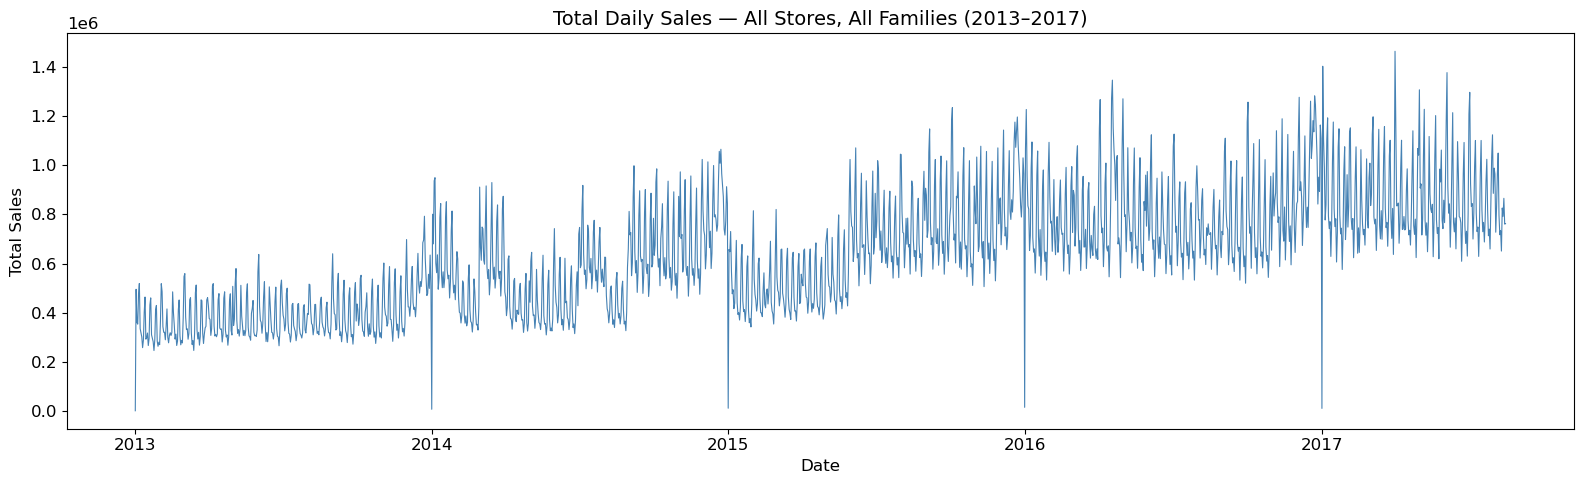

✓ Chart 1: Total sales trend saved


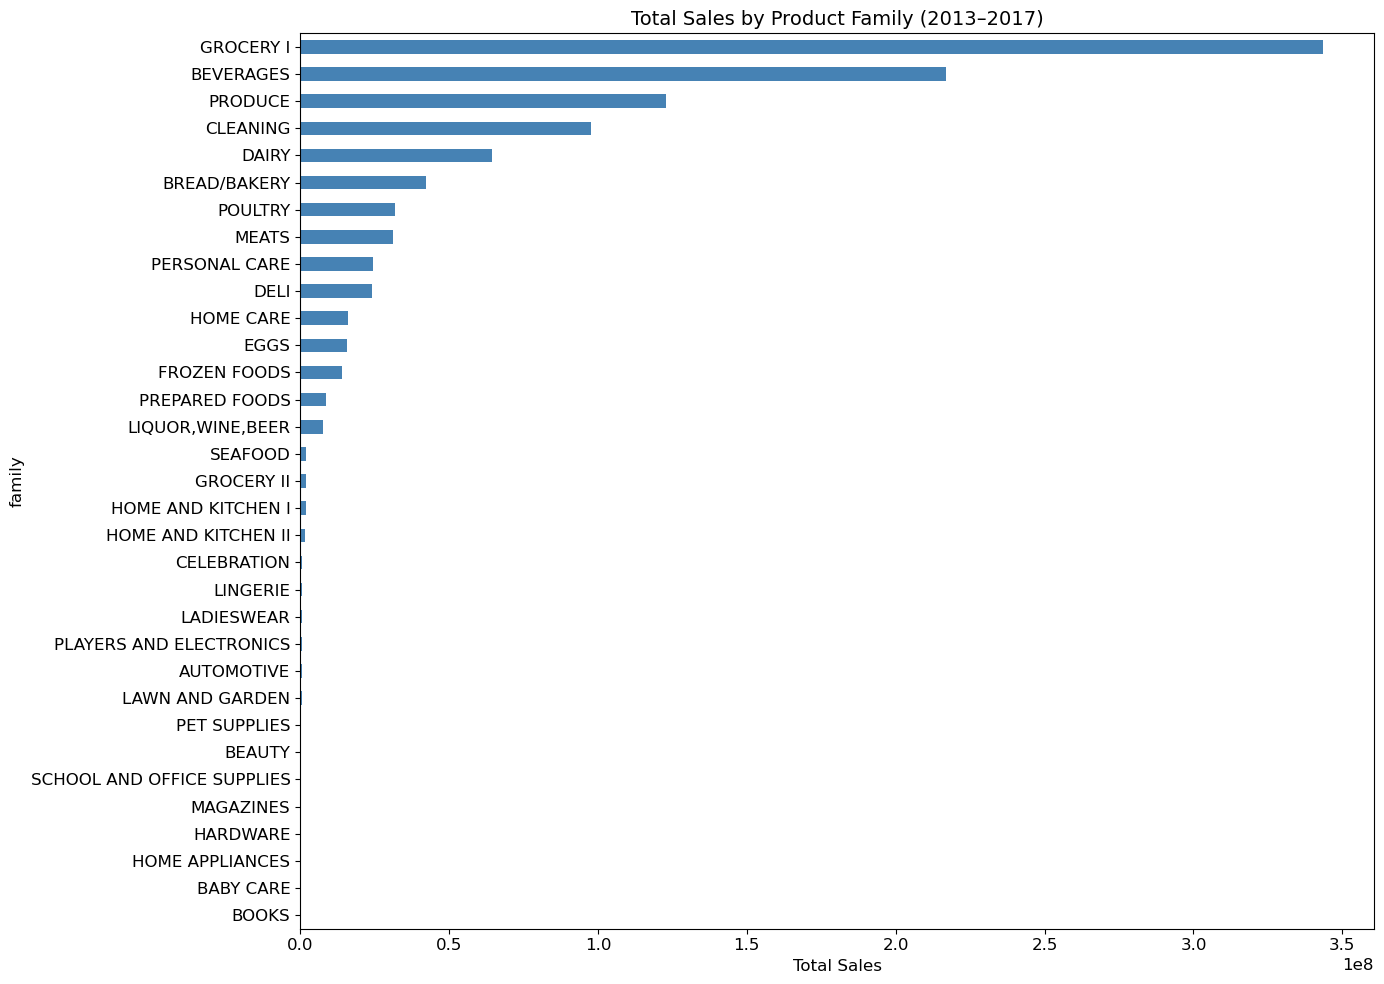

✓ Chart 2: Sales by family saved

Top 5 families by volume:
family
DAIRY        64487708.000
CLEANING     97521288.000
PRODUCE     122704688.000
BEVERAGES   216954480.000
GROCERY I   343462720.000

Bottom 5 families by volume:
family
BOOKS               6438.000
BABY CARE          10051.000
HOME APPLIANCES    41601.000
HARDWARE          103470.000
MAGAZINES         266359.000


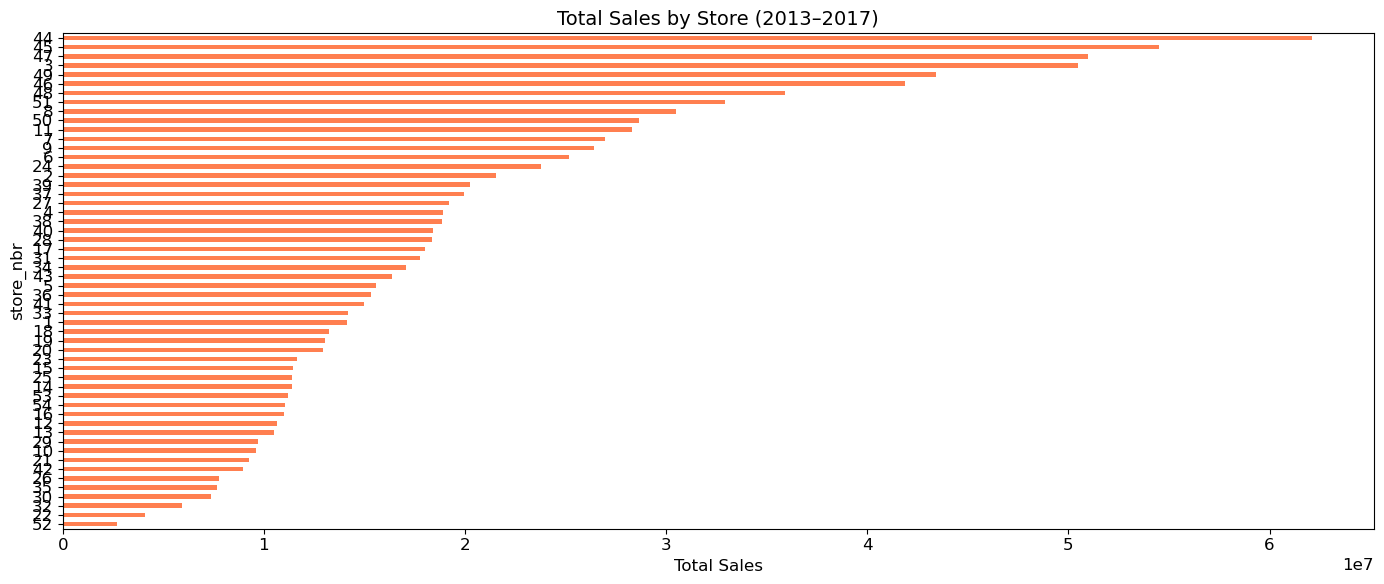

✓ Chart 3: Sales by store saved


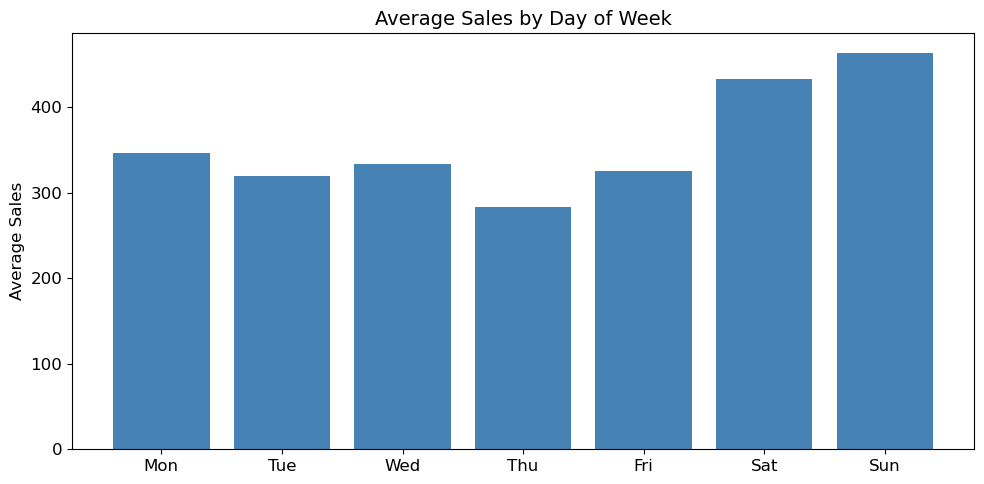

✓ Chart 4: Day of week pattern saved


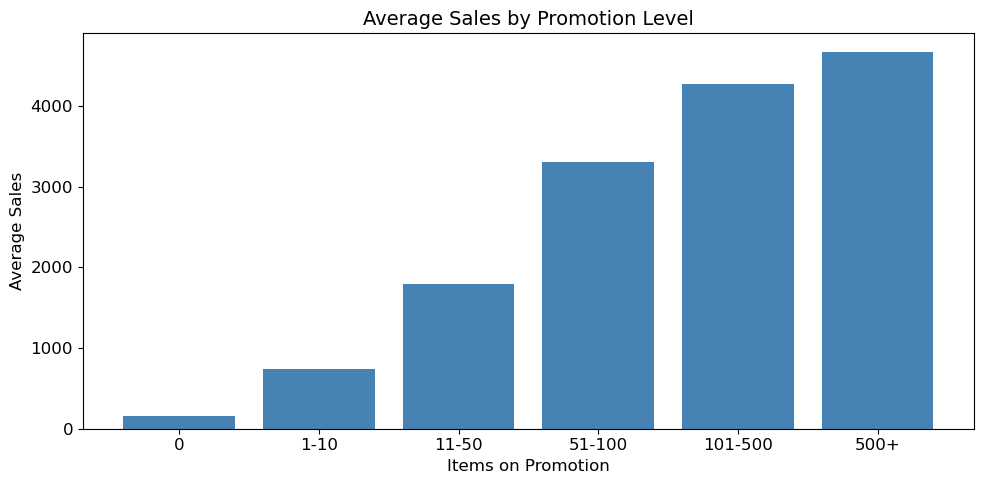

✓ Chart 5: Promotional impact saved


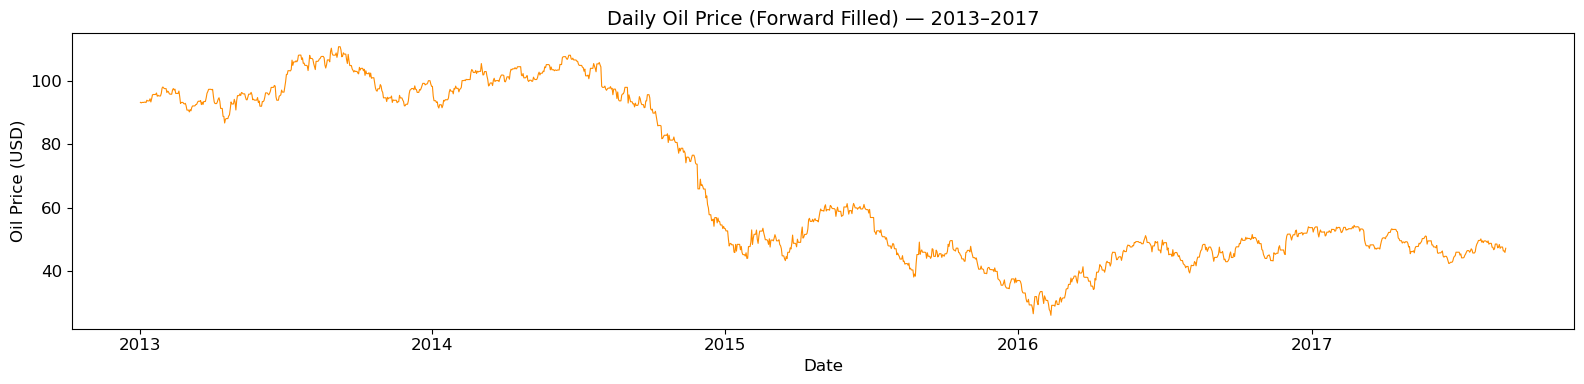

✓ Chart 6: Oil price trend saved


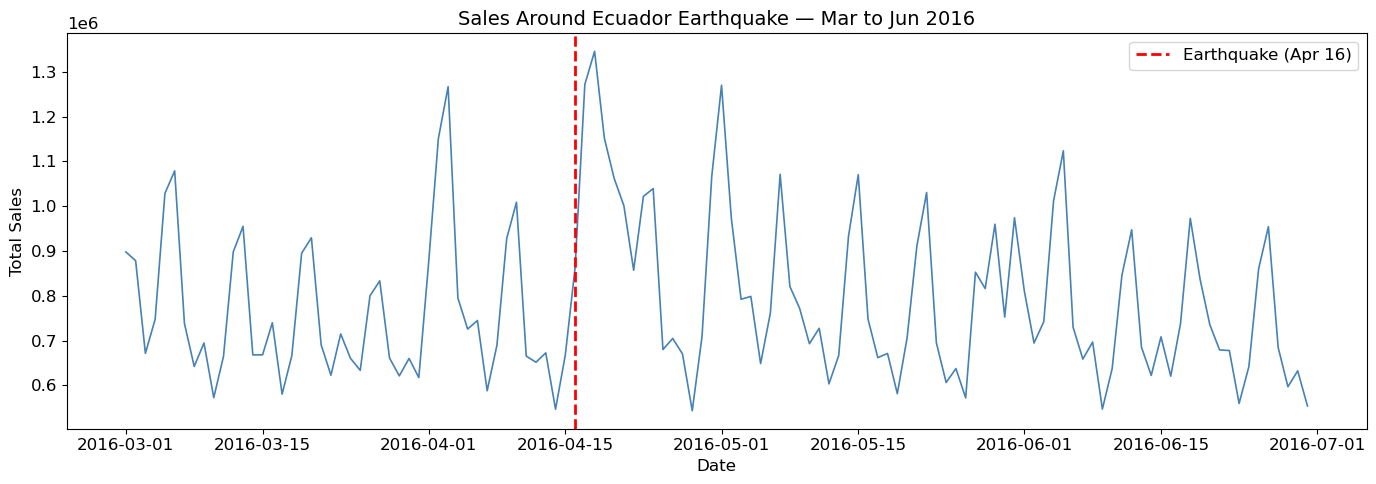

✓ Chart 7: Earthquake impact saved


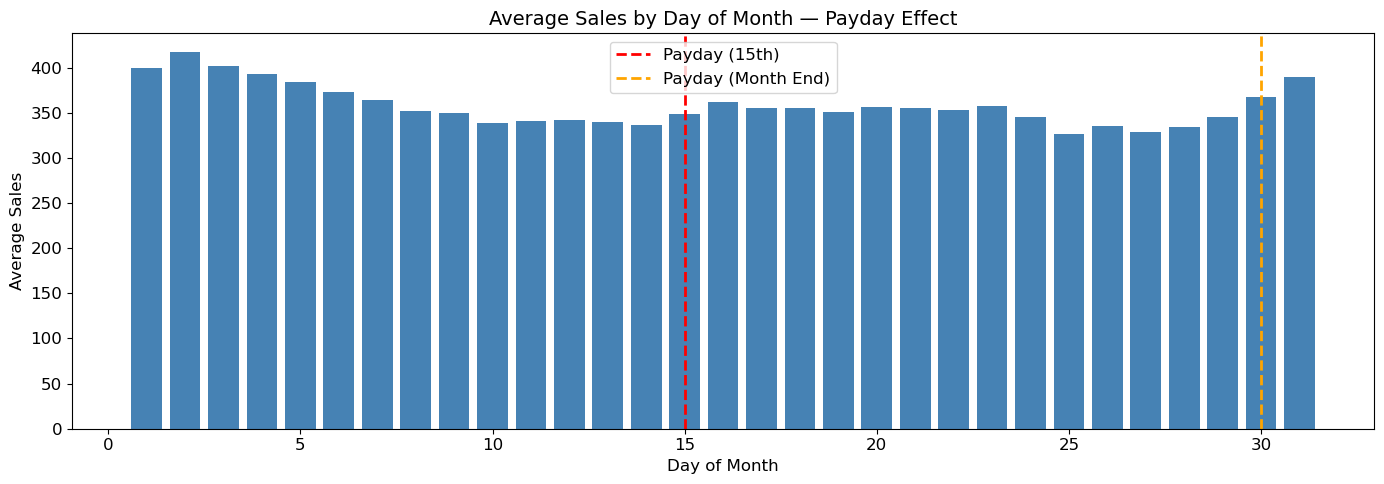

✓ Chart 8: Payday effect saved

✓ EDA COMPLETE — 8 charts generated


In [3]:
# =============================================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS
# =============================================================================
# Goal: Understand sales patterns before building any features or models
# We look at:
#   1. Overall sales trend over time
#   2. Sales by product family — which families dominate?
#   3. Sales by store — any outliers?
#   4. Day of week patterns
#   5. Promotional impact on sales
#   6. Oil price trend
#   7. Transaction patterns
# =============================================================================

# -----------------------------------------------------------------------------
# 3.1 OVERALL SALES TREND OVER TIME
# -----------------------------------------------------------------------------
# Aggregate daily sales across all stores and families
# This gives us the macro picture of how total sales moved 2013-2017

daily_sales = train.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(daily_sales['date'], daily_sales['sales'], linewidth=0.8, color='steelblue')
plt.title('Total Daily Sales — All Stores, All Families (2013–2017)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('eda_01_total_sales_trend.png', dpi=150)
plt.show()
print("✓ Chart 1: Total sales trend saved")

# -----------------------------------------------------------------------------
# 3.2 SALES BY PRODUCT FAMILY
# -----------------------------------------------------------------------------
# Which families drive the most volume?
# This will inform which segments need the most modeling attention

family_sales = train.groupby('family')['sales'].sum().sort_values(ascending=True)

plt.figure(figsize=(14, 10))
family_sales.plot(kind='barh', color='steelblue')
plt.title('Total Sales by Product Family (2013–2017)', fontsize=14)
plt.xlabel('Total Sales')
plt.tight_layout()
plt.savefig('eda_02_sales_by_family.png', dpi=150)
plt.show()
print("✓ Chart 2: Sales by family saved")

# Print top and bottom 5
print("\nTop 5 families by volume:")
print(family_sales.tail(5).to_string())
print("\nBottom 5 families by volume:")
print(family_sales.head(5).to_string())

# -----------------------------------------------------------------------------
# 3.3 SALES BY STORE
# -----------------------------------------------------------------------------
# Are there outlier stores driving disproportionate volume?
# Important for understanding if store clustering is meaningful

store_sales = train.groupby('store_nbr')['sales'].sum().sort_values(ascending=True)

plt.figure(figsize=(14, 6))
store_sales.plot(kind='barh', color='coral')
plt.title('Total Sales by Store (2013–2017)', fontsize=14)
plt.xlabel('Total Sales')
plt.tight_layout()
plt.savefig('eda_03_sales_by_store.png', dpi=150)
plt.show()
print("✓ Chart 3: Sales by store saved")

# -----------------------------------------------------------------------------
# 3.4 DAY OF WEEK PATTERN
# -----------------------------------------------------------------------------
# Retail sales typically peak on weekends
# This will validate whether day-of-week is a useful feature

train['dayofweek'] = train['date'].dt.dayofweek  # 0=Monday, 6=Sunday
dow_sales = train.groupby('dayofweek')['sales'].mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10, 5))
plt.bar(dow_labels, dow_sales.values, color='steelblue')
plt.title('Average Sales by Day of Week', fontsize=14)
plt.ylabel('Average Sales')
plt.tight_layout()
plt.savefig('eda_04_sales_by_dow.png', dpi=150)
plt.show()
print("✓ Chart 4: Day of week pattern saved")

# -----------------------------------------------------------------------------
# 3.5 PROMOTIONAL IMPACT
# -----------------------------------------------------------------------------
# Do promotions actually drive higher sales?
# This validates onpromotion as a key feature

promo_impact = train.groupby('onpromotion')['sales'].mean()

# Bucket onpromotion into ranges for cleaner visualization
train['promo_bucket'] = pd.cut(train['onpromotion'], 
                                bins=[-1, 0, 10, 50, 100, 500, 10000],
                                labels=['0', '1-10', '11-50', '51-100', '101-500', '500+'])

promo_sales = train.groupby('promo_bucket')['sales'].mean()

plt.figure(figsize=(10, 5))
plt.bar(promo_sales.index.astype(str), promo_sales.values, color='steelblue')
plt.title('Average Sales by Promotion Level', fontsize=14)
plt.xlabel('Items on Promotion')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.savefig('eda_05_promo_impact.png', dpi=150)
plt.show()
print("✓ Chart 5: Promotional impact saved")

# -----------------------------------------------------------------------------
# 3.6 OIL PRICE TREND
# -----------------------------------------------------------------------------
# Oil prices drive Ecuador's economy
# Forward fill missing values (weekends/holidays)

oil_filled = oil.set_index('date').reindex(
    pd.date_range(oil['date'].min(), oil['date'].max(), freq='D')
).ffill().reset_index()
oil_filled.columns = ['date', 'dcoilwtico']

plt.figure(figsize=(16, 4))
plt.plot(oil_filled['date'], oil_filled['dcoilwtico'], 
         linewidth=0.8, color='darkorange')
plt.title('Daily Oil Price (Forward Filled) — 2013–2017', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Oil Price (USD)')
plt.tight_layout()
plt.savefig('eda_06_oil_price.png', dpi=150)
plt.show()
print("✓ Chart 6: Oil price trend saved")

# -----------------------------------------------------------------------------
# 3.7 EARTHQUAKE IMPACT
# -----------------------------------------------------------------------------
# Visualize sales around April 16, 2016 earthquake
# Expect surge in essentials followed by normalization

earthquake_date = pd.Timestamp('2016-04-16')
eq_window = daily_sales[
    (daily_sales['date'] >= '2016-03-01') & 
    (daily_sales['date'] <= '2016-06-30')
]

plt.figure(figsize=(14, 5))
plt.plot(eq_window['date'], eq_window['sales'], linewidth=1.2, color='steelblue')
plt.axvline(x=earthquake_date, color='red', linestyle='--', linewidth=2, label='Earthquake (Apr 16)')
plt.title('Sales Around Ecuador Earthquake — Mar to Jun 2016', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.savefig('eda_07_earthquake_impact.png', dpi=150)
plt.show()
print("✓ Chart 7: Earthquake impact saved")

# -----------------------------------------------------------------------------
# 3.8 PAYDAY EFFECT
# -----------------------------------------------------------------------------
# Wages paid on 15th and last day of month
# Expect sales spikes on these dates

train['day'] = train['date'].dt.day
train['is_payday'] = train['day'].isin([15, 31, 28, 29, 30]).astype(int)

# Use day of month to show average sales pattern
dom_sales = train.groupby('day')['sales'].mean()

plt.figure(figsize=(14, 5))
plt.bar(dom_sales.index, dom_sales.values, color='steelblue')
plt.axvline(x=15, color='red', linestyle='--', linewidth=2, label='Payday (15th)')
plt.axvline(x=30, color='orange', linestyle='--', linewidth=2, label='Payday (Month End)')
plt.title('Average Sales by Day of Month — Payday Effect', fontsize=14)
plt.xlabel('Day of Month')
plt.ylabel('Average Sales')
plt.legend()
plt.tight_layout()
plt.savefig('eda_08_payday_effect.png', dpi=150)
plt.show()
print("✓ Chart 8: Payday effect saved")

print()
print("=" * 50)
print("✓ EDA COMPLETE — 8 charts generated")
print("=" * 50)

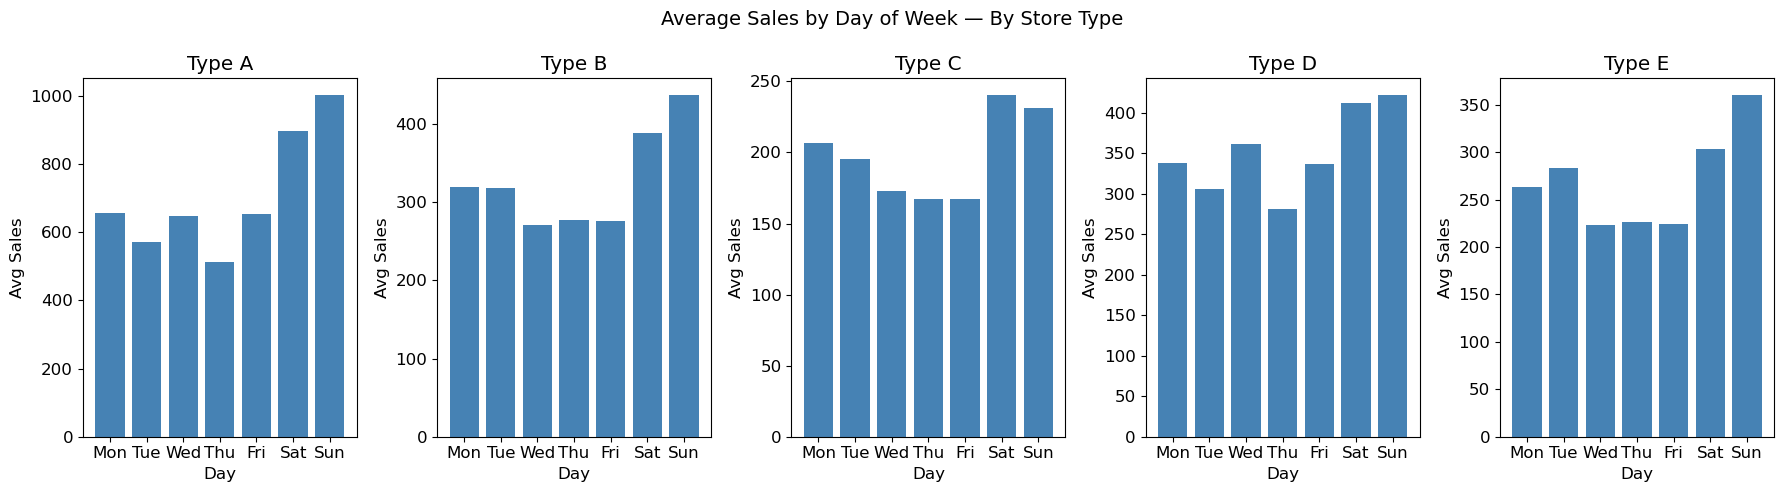

✓ Chart 9: Thursday dip by store type saved

Unique clusters: 17
Store types: ['A', 'B', 'C', 'D', 'E']

Stores per type:
type
A     9
B     8
C    15
D    18
E     4
Name: store_nbr, dtype: int64

Stores per cluster:
cluster
17    1
12    1
16    1
5     1
7     2
9     2
2     2
4     3
8     3
11    3
1     3
13    4
14    4
15    5
10    6
6     6
3     7
Name: store_nbr, dtype: int64


In [4]:
# =============================================================================
# SECTION 3.9 — THURSDAY DIP ANALYSIS BY STORE TYPE & CLUSTER
# =============================================================================
# Hypothesis: Thursday dip is a supply-side restocking artifact
# affecting mid-segment stores more than large or small stores
# We verify by breaking down day-of-week sales by store type and cluster
# =============================================================================

# First merge store metadata into train
train_stores = train.merge(stores, on='store_nbr', how='left')

# Day of week sales by STORE TYPE
dow_by_type = train_stores.groupby(['type', 'dayofweek'])['sales'].mean().reset_index()
dow_by_type['day_name'] = dow_by_type['dayofweek'].map(
    {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})

store_types = dow_by_type['type'].unique()

fig, axes = plt.subplots(1, len(store_types), figsize=(18, 5), sharey=False)
fig.suptitle('Average Sales by Day of Week — By Store Type', fontsize=14)

for i, stype in enumerate(sorted(store_types)):
    data = dow_by_type[dow_by_type['type'] == stype]
    axes[i].bar(data['day_name'], data['sales'], color='steelblue')
    axes[i].set_title(f'Type {stype}')
    axes[i].set_xlabel('Day')
    axes[i].set_ylabel('Avg Sales')

plt.tight_layout()
plt.savefig('eda_09_thursday_by_store_type.png', dpi=150)
plt.show()
print("✓ Chart 9: Thursday dip by store type saved")

# Day of week sales by CLUSTER
dow_by_cluster = train_stores.groupby(['cluster', 'dayofweek'])['sales'].mean().reset_index()
dow_by_cluster['day_name'] = dow_by_cluster['dayofweek'].map(
    {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})

# How many clusters?
print(f"\nUnique clusters: {train_stores['cluster'].nunique()}")
print(f"Store types: {sorted(train_stores['type'].unique())}")
print(f"\nStores per type:")
print(train_stores.groupby('type')['store_nbr'].nunique())
print(f"\nStores per cluster:")
print(train_stores.groupby('cluster')['store_nbr'].nunique().sort_values())

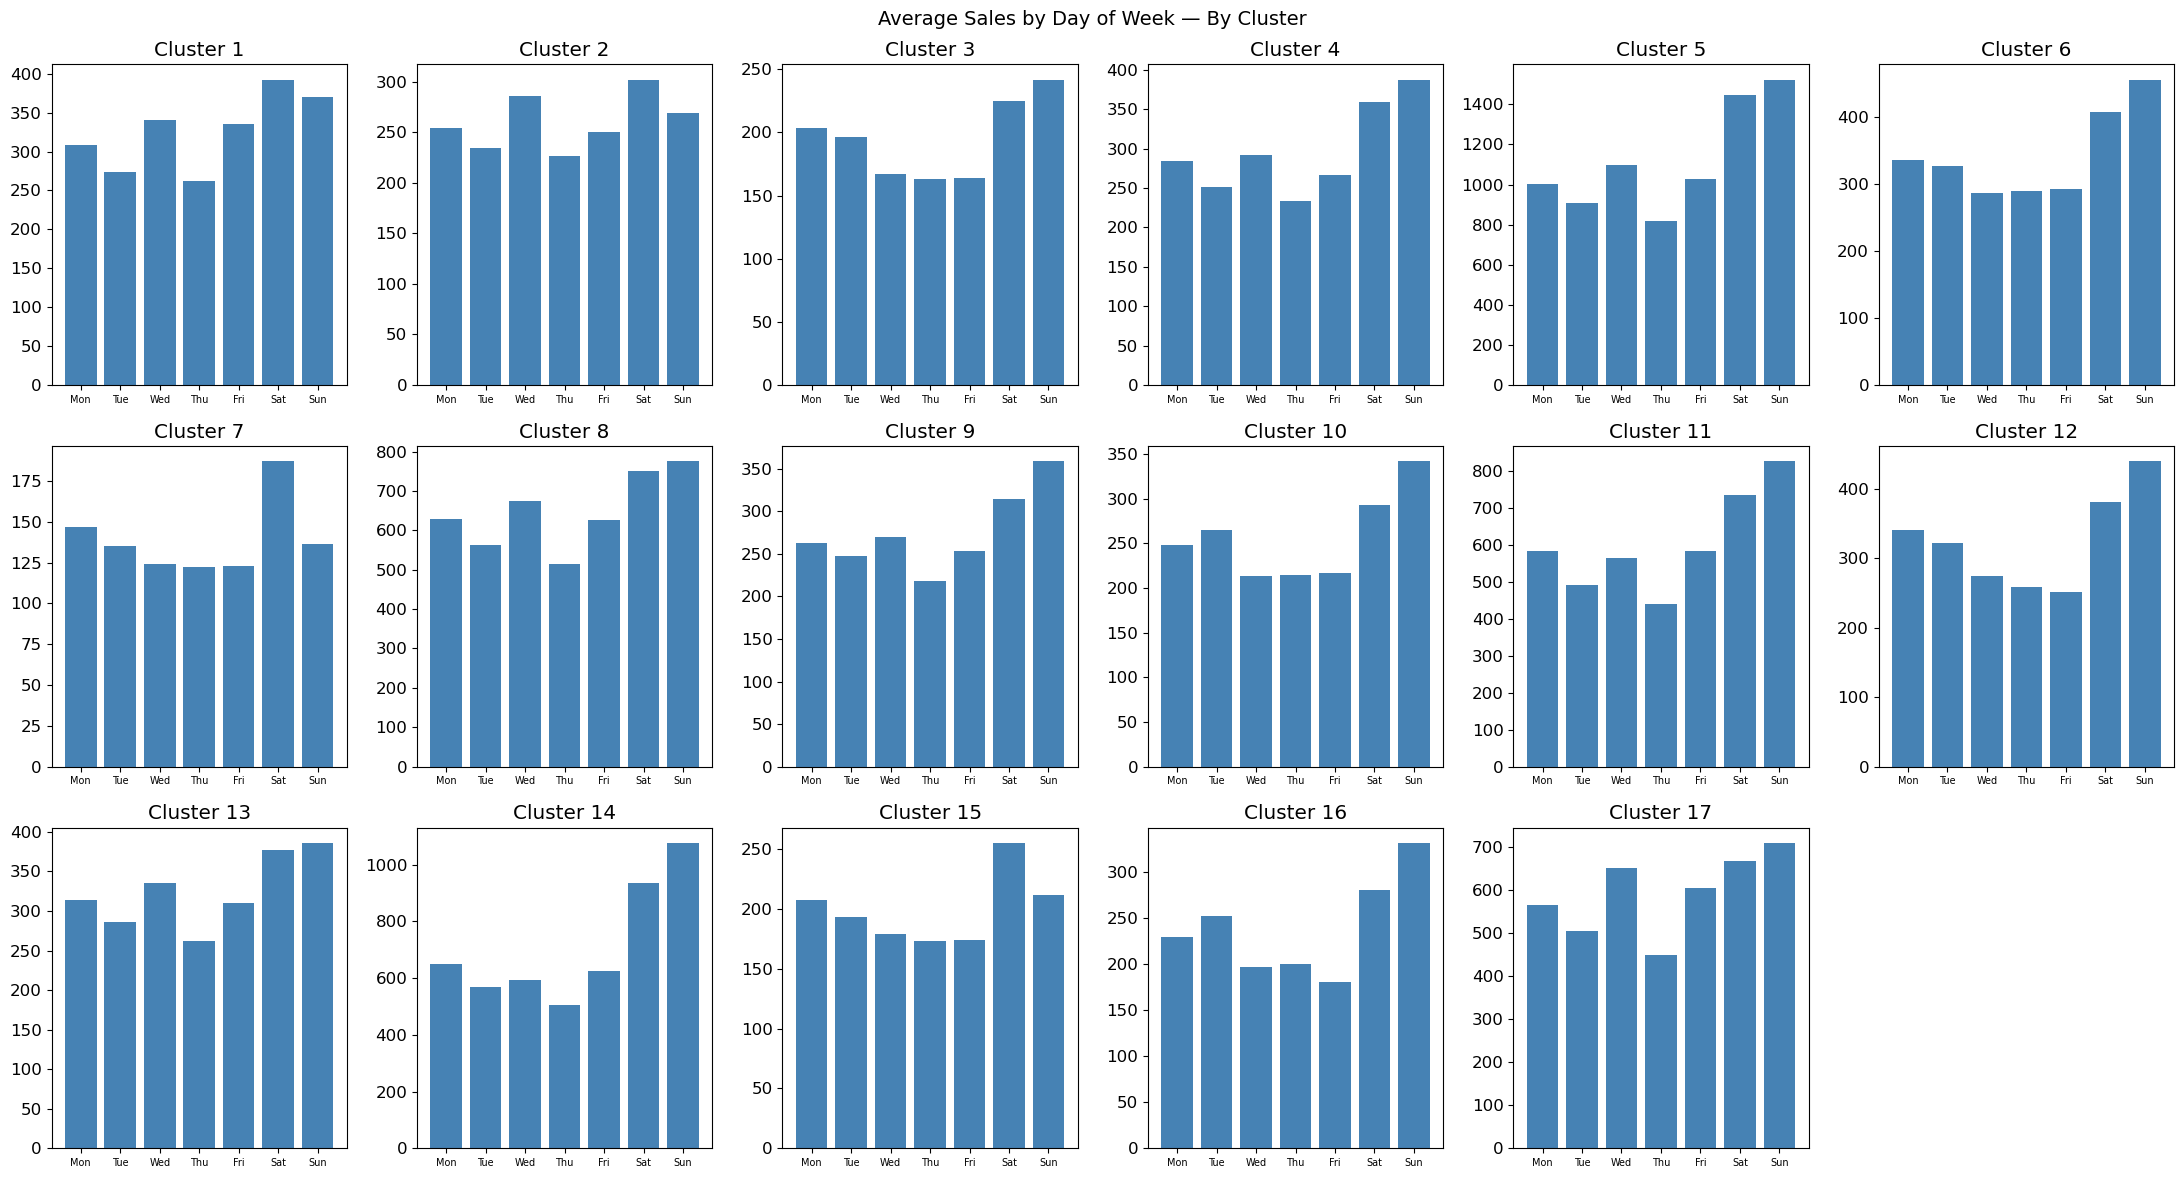

✓ Chart 10: Thursday dip by cluster saved


In [5]:
# =============================================================================
# SECTION 3.10 — THURSDAY DIP ANALYSIS BY CLUSTER
# =============================================================================

clusters = sorted(train_stores['cluster'].unique())
n_clusters = len(clusters)

# Plot in a grid — 17 clusters, use 3 rows x 6 cols
fig, axes = plt.subplots(3, 6, figsize=(22, 12), sharey=False)
fig.suptitle('Average Sales by Day of Week — By Cluster', fontsize=14)
axes = axes.flatten()

for i, cluster in enumerate(clusters):
    data = dow_by_cluster[dow_by_cluster['cluster'] == cluster]
    axes[i].bar(data['day_name'], data['sales'], color='steelblue')
    axes[i].set_title(f'Cluster {cluster}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=7)

# Hide the last empty subplot (17 clusters, 18 slots)
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('eda_10_thursday_by_cluster.png', dpi=150)
plt.show()
print("✓ Chart 10: Thursday dip by cluster saved")

STORE SUMMARY — Top 15 by Total Sales
 store_nbr type  cluster      city      state  total_sales  avg_daily_sales  zero_sales_pct
        44    A        5     Quito  Pichincha 62087552.000         1117.245          17.948
        45    A       11     Quito  Pichincha 54498012.000          980.674          19.359
        47    A       14     Quito  Pichincha 50948312.000          916.798          18.954
         3    D        8     Quito  Pichincha 50481912.000          908.406          18.140
        49    A       11     Quito  Pichincha 43420096.000          781.330          19.348
        46    A       14     Quito  Pichincha 41896064.000          753.906          19.321
        48    A       14     Quito  Pichincha 35933132.000          646.605          21.322
        51    A       17 Guayaquil     Guayas 32911490.000          592.232          20.122
         8    D        8     Quito  Pichincha 30494286.000          548.735          19.931
        50    A       14    Ambato Tungura

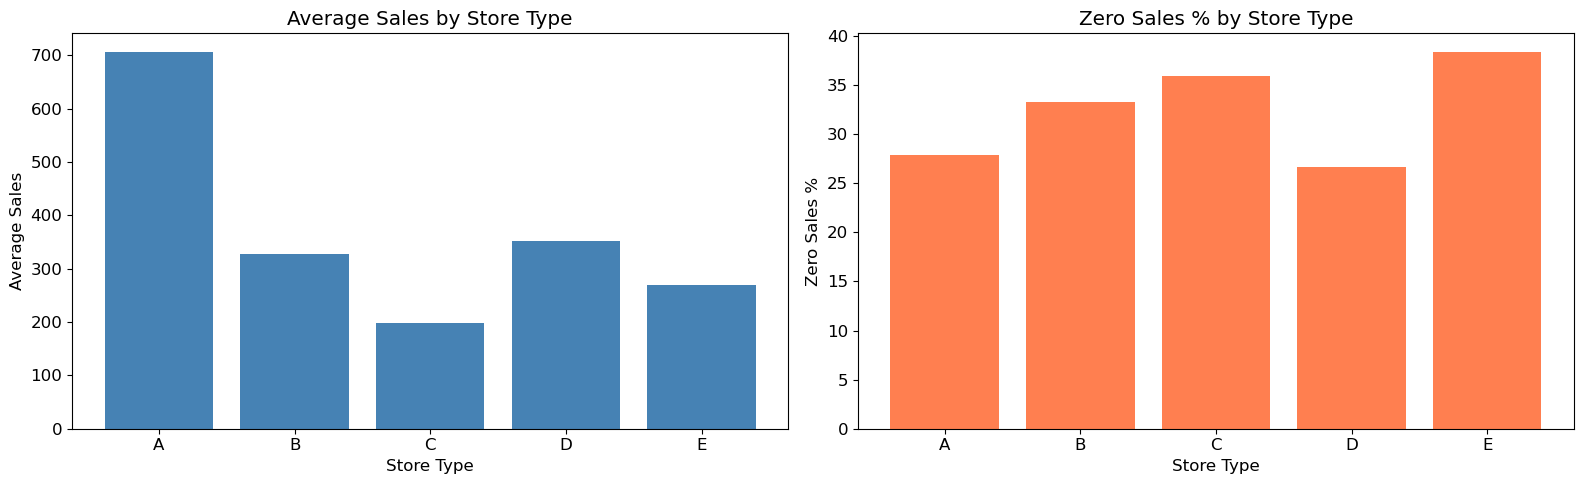

✓ Chart 11: Store type analysis saved


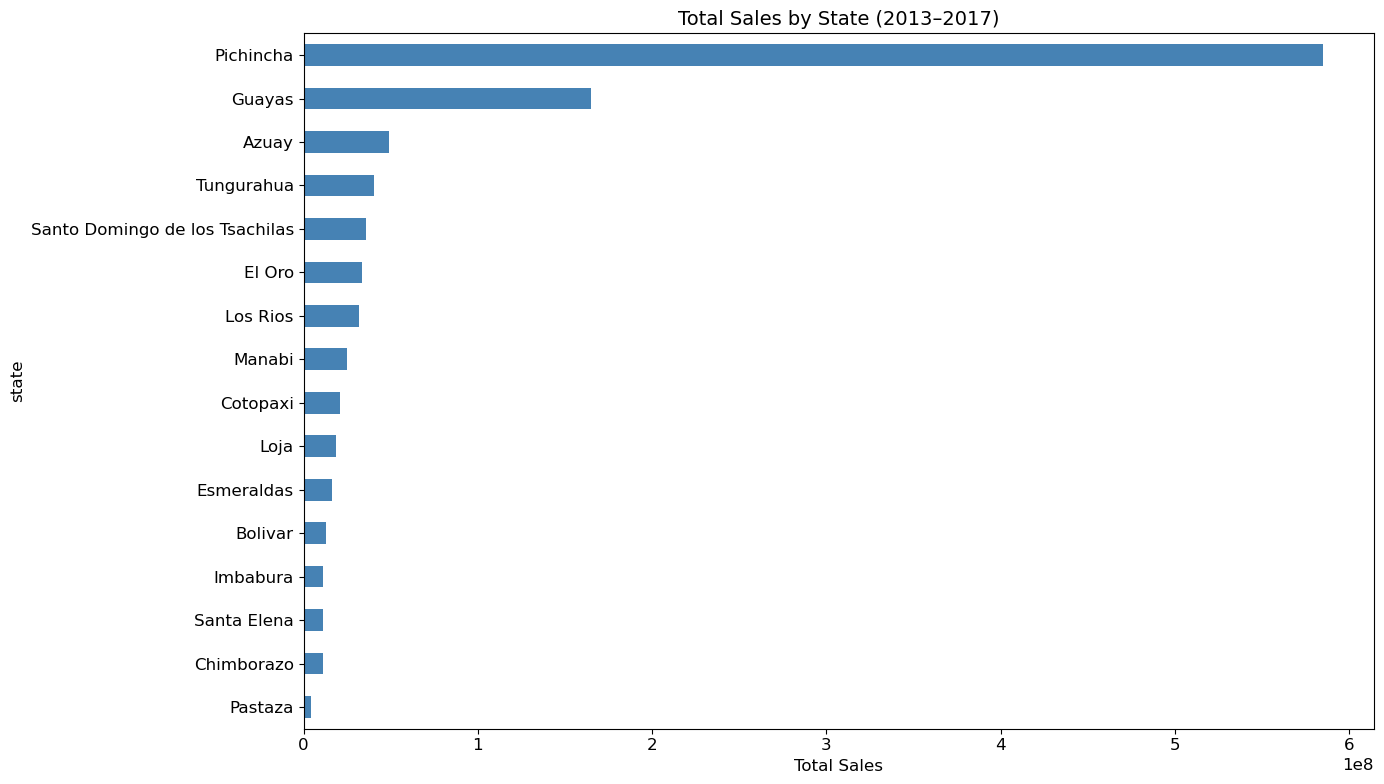

✓ Chart 12: Sales by state saved

States in dataset:
state
Pichincha                         19
Guayas                            11
Azuay                              3
Manabi                             3
Santo Domingo de los Tsachilas     3
Cotopaxi                           2
El Oro                             2
Los Rios                           2
Tungurahua                         2
Bolivar                            1
Chimborazo                         1
Esmeraldas                         1
Imbabura                           1
Loja                               1
Pastaza                            1
Santa Elena                        1
Name: store_nbr, dtype: int64


In [6]:
# =============================================================================
# SECTION 3.11 — STORE TYPE & CLUSTER DEEP DIVE
# =============================================================================
# Understand what store types and clusters represent
# This will directly inform our demand classification strategy
# =============================================================================

# Store type distribution with sales context
store_summary = train_stores.groupby(['store_nbr', 'type', 'cluster', 'city', 'state']).agg(
    total_sales=('sales', 'sum'),
    avg_daily_sales=('sales', 'mean'),
    zero_sales_pct=('sales', lambda x: (x==0).mean() * 100)
).reset_index().sort_values('total_sales', ascending=False)

print("=" * 60)
print("STORE SUMMARY — Top 15 by Total Sales")
print("=" * 60)
print(store_summary.head(15).to_string(index=False))

print()
print("=" * 60)
print("STORE SUMMARY — Bottom 15 by Total Sales")
print("=" * 60)
print(store_summary.tail(15).to_string(index=False))

print()
print("=" * 60)
print("AVERAGE SALES & ZERO % BY STORE TYPE")
print("=" * 60)
type_summary = train_stores.groupby('type').agg(
    num_stores=('store_nbr', 'nunique'),
    avg_sales=('sales', 'mean'),
    zero_pct=('sales', lambda x: (x==0).mean() * 100)
).round(2)
print(type_summary)

# Visualize store type vs avg sales
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Avg sales by type
type_avg = train_stores.groupby('type')['sales'].mean()
axes[0].bar(type_avg.index, type_avg.values, color='steelblue')
axes[0].set_title('Average Sales by Store Type')
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Average Sales')

# Zero sales % by type
type_zero = train_stores.groupby('type')['sales'].apply(lambda x: (x==0).mean()*100)
axes[1].bar(type_zero.index, type_zero.values, color='coral')
axes[1].set_title('Zero Sales % by Store Type')
axes[1].set_xlabel('Store Type')
axes[1].set_ylabel('Zero Sales %')

plt.tight_layout()
plt.savefig('eda_11_store_type_analysis.png', dpi=150)
plt.show()
print("✓ Chart 11: Store type analysis saved")

# =============================================================================
# SECTION 3.12 — STATE LEVEL ANALYSIS
# =============================================================================
# Which states drive most volume?
# Important for earthquake regional impact features

state_sales = train_stores.groupby('state')['sales'].sum().sort_values(ascending=True)

plt.figure(figsize=(14, 8))
state_sales.plot(kind='barh', color='steelblue')
plt.title('Total Sales by State (2013–2017)', fontsize=14)
plt.xlabel('Total Sales')
plt.tight_layout()
plt.savefig('eda_12_sales_by_state.png', dpi=150)
plt.show()
print("✓ Chart 12: Sales by state saved")

# Print state list — important for earthquake flag mapping
print("\nStates in dataset:")
print(train_stores.groupby('state')['store_nbr'].nunique().sort_values(ascending=False))

TRANSACTIONS OVERVIEW
Date range: 2013-01-01 to 2017-08-15
Avg daily transactions per store: 1695
Max daily transactions: 8,359
Min daily transactions: 5

AVG TRANSACTIONS BY STORE TYPE
type
A   3193.000
B   1756.000
C   1032.000
D   1619.000
E   1188.000
Name: transactions, dtype: float64


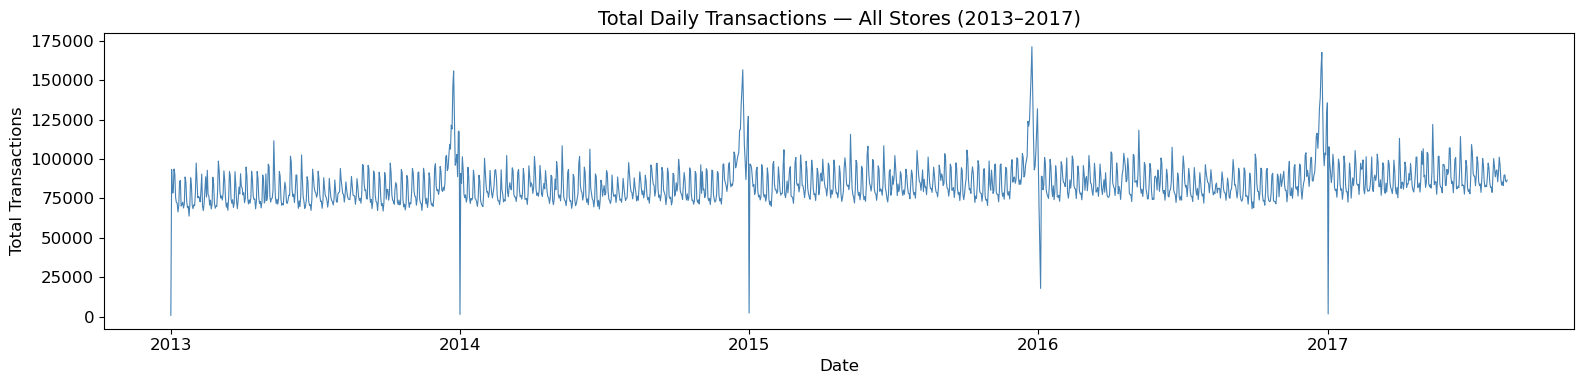

✓ Chart 13: Transactions trend saved


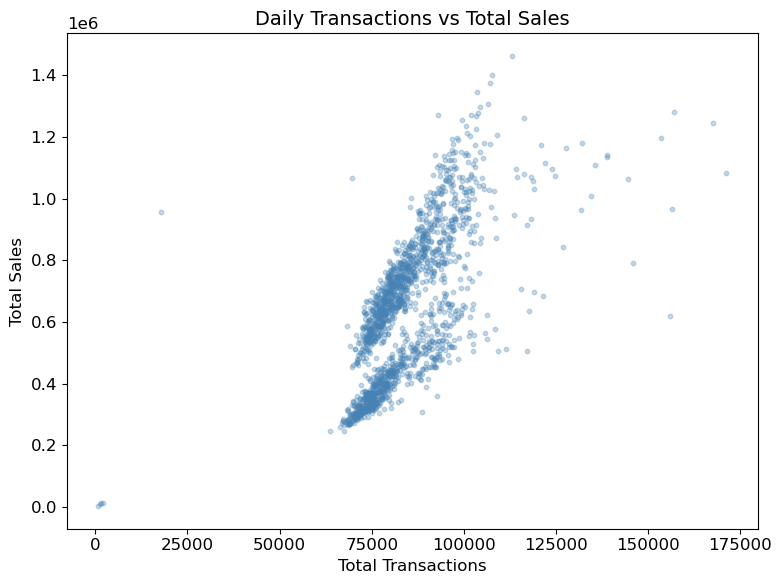

✓ Chart 14: Transactions vs Sales saved

Correlation between transactions and sales: 0.677


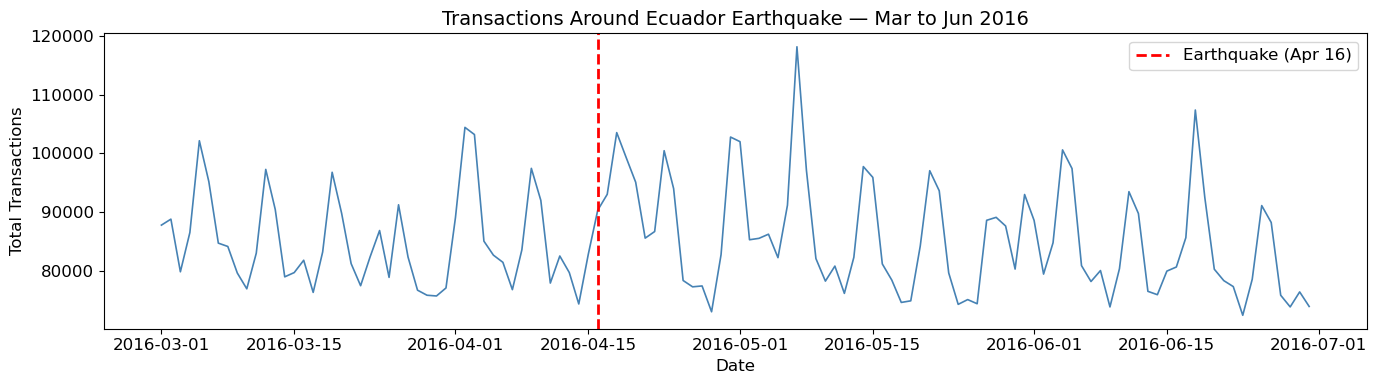

✓ Chart 15: Transactions around earthquake saved

✓ EDA COMPLETE — ALL SECTIONS DONE


In [7]:
# =============================================================================
# SECTION 3.13 — TRANSACTIONS ANALYSIS
# =============================================================================
# Transactions = number of customer visits per store per day
# This is a bonus feature not available in the original competition
# High transactions + low sales = small basket size (convenience shopping)
# Low transactions + high sales = large basket size (bulk/weekend shopping)
# =============================================================================

# Merge transactions with store metadata
trans_stores = transactions.merge(stores, on='store_nbr', how='left')

print("=" * 50)
print("TRANSACTIONS OVERVIEW")
print("=" * 50)
print(f"Date range: {transactions['date'].min().date()} to {transactions['date'].max().date()}")
print(f"Avg daily transactions per store: {transactions['transactions'].mean():.0f}")
print(f"Max daily transactions: {transactions['transactions'].max():,}")
print(f"Min daily transactions: {transactions['transactions'].min():,}")
print()

# -----------------------------------------------------------------------------
# Transactions by store type
# -----------------------------------------------------------------------------
print("=" * 50)
print("AVG TRANSACTIONS BY STORE TYPE")
print("=" * 50)
print(trans_stores.groupby('type')['transactions'].mean().round(0))

# -----------------------------------------------------------------------------
# Transactions trend over time
# -----------------------------------------------------------------------------
daily_trans = transactions.groupby('date')['transactions'].sum().reset_index()

plt.figure(figsize=(16, 4))
plt.plot(daily_trans['date'], daily_trans['transactions'], 
         linewidth=0.8, color='steelblue')
plt.title('Total Daily Transactions — All Stores (2013–2017)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Transactions')
plt.tight_layout()
plt.savefig('eda_13_transactions_trend.png', dpi=150)
plt.show()
print("✓ Chart 13: Transactions trend saved")

# -----------------------------------------------------------------------------
# Transactions vs Sales correlation
# -----------------------------------------------------------------------------
# Merge daily transactions with daily sales
daily_sales_trans = train.groupby('date')['sales'].sum().reset_index()
daily_sales_trans = daily_sales_trans.merge(daily_trans, on='date', how='left')

plt.figure(figsize=(8, 6))
plt.scatter(daily_sales_trans['transactions'], 
            daily_sales_trans['sales'], 
            alpha=0.3, color='steelblue', s=10)
plt.title('Daily Transactions vs Total Sales', fontsize=14)
plt.xlabel('Total Transactions')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('eda_14_transactions_vs_sales.png', dpi=150)
plt.show()

# Correlation
corr = daily_sales_trans[['sales','transactions']].corr().iloc[0,1]
print(f"✓ Chart 14: Transactions vs Sales saved")
print(f"\nCorrelation between transactions and sales: {corr:.3f}")

# -----------------------------------------------------------------------------
# Transactions around earthquake
# -----------------------------------------------------------------------------
eq_trans = transactions[
    (transactions['date'] >= '2016-03-01') & 
    (transactions['date'] <= '2016-06-30')
].groupby('date')['transactions'].sum().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(eq_trans['date'], eq_trans['transactions'], 
         linewidth=1.2, color='steelblue')
plt.axvline(x=pd.Timestamp('2016-04-16'), color='red', 
            linestyle='--', linewidth=2, label='Earthquake (Apr 16)')
plt.title('Transactions Around Ecuador Earthquake — Mar to Jun 2016', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Transactions')
plt.legend()
plt.tight_layout()
plt.savefig('eda_15_transactions_earthquake.png', dpi=150)
plt.show()
print("✓ Chart 15: Transactions around earthquake saved")

print()
print("=" * 50)
print("✓ EDA COMPLETE — ALL SECTIONS DONE")
print("=" * 50)

In [8]:
# =============================================================================
# SECTION 4: DATA PREPROCESSING & MERGING
# =============================================================================
# Before feature engineering we need a clean, merged master dataframe
# Steps:
#   1. Fix oil prices (forward fill gaps)
#   2. Process holidays (handle transferred flag)
#   3. Merge all files into one master dataframe
#   4. Add store age
#   5. Add earthquake flags
#   6. Combine train + test into one frame for feature engineering
#      (we engineer features on both simultaneously to avoid leakage)
# =============================================================================

# -----------------------------------------------------------------------------
# 4.1 FIX OIL PRICES — forward fill weekend/holiday gaps
# -----------------------------------------------------------------------------

oil_complete = oil.set_index('date').reindex(
    pd.date_range(oil['date'].min(), '2017-08-31', freq='D')
).ffill().reset_index()
oil_complete.columns = ['date', 'oil_price']

print(f"Oil prices — before fill: {oil['dcoilwtico'].isnull().sum()} missing")
print(f"Oil prices — after fill:  {oil_complete['oil_price'].isnull().sum()} missing")
print("✓ Oil prices forward filled")

# -----------------------------------------------------------------------------
# 4.2 PROCESS HOLIDAYS
# -----------------------------------------------------------------------------

holidays_clean = holidays[
    ~((holidays['transferred'] == True) | (holidays['type'] == 'Work Day'))
].copy()
holidays_clean['is_holiday'] = 1

holidays_national = holidays_clean[
    holidays_clean['locale'] == 'National'
][['date', 'is_holiday']].drop_duplicates()
holidays_national.columns = ['date', 'is_national_holiday']

holidays_regional = holidays_clean[
    holidays_clean['locale'] == 'Regional'
][['date', 'locale_name', 'is_holiday']].drop_duplicates()
holidays_regional.columns = ['date', 'state', 'is_regional_holiday']

holidays_local = holidays_clean[
    holidays_clean['locale'] == 'Local'
][['date', 'locale_name', 'is_holiday']].drop_duplicates()
holidays_local.columns = ['date', 'city', 'is_local_holiday']

print("✓ Holidays processed")

# -----------------------------------------------------------------------------
# 4.3 COMBINE TRAIN + TEST
# -----------------------------------------------------------------------------

train['is_train'] = 1
test['is_train'] = 0
test['sales'] = np.nan

test = test[['date', 'store_nbr', 'family', 'onpromotion', 'sales', 'is_train']]
train_proc = train[['date', 'store_nbr', 'family', 'onpromotion', 'sales', 'is_train']].copy()

df = pd.concat([train_proc, test], axis=0).reset_index(drop=True)
df = df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

print(f"\n✓ Train + Test combined: {df.shape[0]:,} rows")

# -----------------------------------------------------------------------------
# 4.4 MERGE STORE METADATA
# -----------------------------------------------------------------------------
df = df.merge(stores, on='store_nbr', how='left')
print("✓ Store metadata merged")

# -----------------------------------------------------------------------------
# 4.5 MERGE OIL PRICES
# -----------------------------------------------------------------------------
df = df.merge(oil_complete, on='date', how='left')
print("✓ Oil prices merged")

# -----------------------------------------------------------------------------
# 4.6 MERGE TRANSACTIONS
# -----------------------------------------------------------------------------
# Merge actual transactions for all dates we have data for
# Test period (Aug 16-31) transactions will be forecasted in Section 4.13
# and filled back into df before feature engineering

df = df.merge(transactions, on=['date', 'store_nbr'], how='left')
print(f"✓ Transactions merged")
print(f"  Train transactions missing: {df[df['is_train']==1]['transactions'].isnull().sum()}")
print(f"  Test transactions missing:  {df[df['is_train']==0]['transactions'].isnull().sum()}")

# -----------------------------------------------------------------------------
# 4.7 MERGE NATIONAL HOLIDAYS
# -----------------------------------------------------------------------------
df = df.merge(holidays_national, on='date', how='left')
df['is_national_holiday'] = df['is_national_holiday'].fillna(0).astype('int8')
print("✓ National holidays merged")

# -----------------------------------------------------------------------------
# 4.8 MERGE REGIONAL HOLIDAYS
# -----------------------------------------------------------------------------
df = df.merge(holidays_regional, on=['date', 'state'], how='left')
df['is_regional_holiday'] = df['is_regional_holiday'].fillna(0).astype('int8')
print("✓ Regional holidays merged")

# -----------------------------------------------------------------------------
# 4.9 MERGE LOCAL HOLIDAYS
# -----------------------------------------------------------------------------
df = df.merge(holidays_local, on=['date', 'city'], how='left')
df['is_local_holiday'] = df['is_local_holiday'].fillna(0).astype('int8')
print("✓ Local holidays merged")

# -----------------------------------------------------------------------------
# 4.10 STORE AGE
# -----------------------------------------------------------------------------
first_sale = train.groupby('store_nbr')['date'].min().reset_index()
first_sale.columns = ['store_nbr', 'store_open_date']
df = df.merge(first_sale, on='store_nbr', how='left')
df['store_age_days'] = (df['date'] - df['store_open_date']).dt.days
print("✓ Store age calculated")

# -----------------------------------------------------------------------------
# 4.11 EARTHQUAKE FLAGS
# -----------------------------------------------------------------------------
earthquake_date = pd.Timestamp('2016-04-16')

df['days_since_earthquake'] = (df['date'] - earthquake_date).dt.days.clip(lower=0)

manabi_stores = [52, 53, 54]
df['eq_manabi_store'] = df['store_nbr'].isin(manabi_stores).astype('int8')

df['eq_surge_window'] = (
    (df['date'] > earthquake_date) & 
    (df['date'] <= earthquake_date + pd.Timedelta(days=15))
).astype('int8')

df['eq_recovery_window'] = (
    (df['date'] > earthquake_date + pd.Timedelta(days=15)) & 
    (df['date'] <= earthquake_date + pd.Timedelta(days=30))
).astype('int8')

df['eq_manabi_disruption'] = (
    (df['eq_manabi_store'] == 1) & 
    (df['days_since_earthquake'] <= 30)
).astype('int8')

print("✓ Earthquake flags created")

# -----------------------------------------------------------------------------
# 4.12 MEMORY OPTIMIZATION
# -----------------------------------------------------------------------------
df['oil_price'] = df['oil_price'].bfill()
df['oil_price'] = df['oil_price'].astype('float32')
df['transactions'] = df['transactions'].astype('float32')
df['store_age_days'] = df['store_age_days'].astype('int32')
df['days_since_earthquake'] = df['days_since_earthquake'].astype('int16')
df['is_train'] = df['is_train'].astype('int8')
df['family'] = df['family'].astype('category')
df['city'] = df['city'].astype('category')
df['state'] = df['state'].astype('category')
df['type'] = df['type'].astype('category')

print(f"\nMaster dataframe shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()
print("✓ Preprocessing complete — master dataframe ready")

Oil prices — before fill: 43 missing
Oil prices — after fill:  1 missing
✓ Oil prices forward filled
✓ Holidays processed

✓ Train + Test combined: 3,029,400 rows
✓ Store metadata merged
✓ Oil prices merged
✓ Transactions merged
  Train transactions missing: 245784
  Test transactions missing:  28512
✓ National holidays merged
✓ Regional holidays merged
✓ Local holidays merged
✓ Store age calculated
✓ Earthquake flags created

Master dataframe shape: (3029400, 22)
Memory usage: 150.2 MB

✓ Preprocessing complete — master dataframe ready


In [9]:
# =============================================================================
# SECTION 4.13: FORECAST TRANSACTIONS FOR TEST PERIOD (Aug 16-31)
# =============================================================================
# We cannot use actual transactions for test dates — they don't exist yet
# We build a proper forecast using LightGBM + Prophet + blend
# This respects YoY growth trend, weekly patterns, store characteristics
# Output: 54 stores × 16 days = 864 transaction forecasts
# =============================================================================

print("=" * 60)
print("SECTION 4.13: TRANSACTION FORECASTING")
print("=" * 60)

# -----------------------------------------------------------------------------
# 4.13.1 PREPARE TRANSACTION TRAINING DATA
# -----------------------------------------------------------------------------
# Use actual transaction data Jan 2013 → Aug 15, 2017

trans_train = transactions.copy()
trans_train = trans_train.merge(stores[['store_nbr', 'cluster', 'type']], 
                                 on='store_nbr', how='left')
trans_train = trans_train.merge(stores[['store_nbr', 'state', 'city']], 
                                 on='store_nbr', how='left', suffixes=('', '_dup'))
trans_train = trans_train.merge(holidays_national, on='date', how='left')
trans_train = trans_train.merge(holidays_regional, on=['date', 'state'], how='left')
trans_train = trans_train.merge(holidays_local, on=['date', 'city'], how='left')
trans_train['is_national_holiday'] = trans_train['is_national_holiday'].fillna(0).astype('int8')
trans_train['is_regional_holiday'] = trans_train['is_regional_holiday'].fillna(0).astype('int8')
trans_train['is_local_holiday'] = trans_train['is_local_holiday'].fillna(0).astype('int8')

earthquake_date = pd.Timestamp('2016-04-16')
trans_train['days_since_earthquake'] = (trans_train['date'] - earthquake_date).dt.days.clip(lower=0)
manabi_stores = [52, 53, 54]
trans_train['eq_manabi_store'] = trans_train['store_nbr'].isin(manabi_stores).astype('int8')
trans_train = trans_train.sort_values(['store_nbr', 'date']).reset_index(drop=True)

# Encode store type
type_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
trans_train['type_enc'] = trans_train['type'].map(type_map)

# Calendar features
trans_train['dayofweek']  = trans_train['date'].dt.dayofweek
trans_train['month']      = trans_train['date'].dt.month
trans_train['day']        = trans_train['date'].dt.day
trans_train['year']       = trans_train['date'].dt.year
trans_train['is_weekend'] = (trans_train['dayofweek'] >= 5).astype(int)
trans_train['weekofyear'] = trans_train['date'].dt.isocalendar().week.astype(int)

# Lag features for transactions — includes short lags 1-6, same insight
# validated on the main sales model (true day-to-day recency was the
# single highest-value addition found today)
for lag in [1, 2, 3, 4, 5, 6, 7, 14, 28, 364]:
    trans_train[f'trans_lag_{lag}'] = trans_train.groupby('store_nbr')['transactions'].transform(
        lambda x: x.shift(lag)
    )

# Rolling mean features — includes micro-windows 2-6 plus medium-band 21/42
for window in [2, 3, 4, 5, 6, 7, 14, 21, 28, 42]:
    trans_train[f'trans_roll_{window}'] = trans_train.groupby('store_nbr')['transactions'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean()
    )

# YoY growth — ratio of recent 30 days vs same period last year
trans_train['trans_lag_364_roll28'] = trans_train.groupby('store_nbr')['transactions'].transform(
    lambda x: x.shift(364).rolling(28, min_periods=1).mean()
)
trans_train['yoy_ratio'] = trans_train.groupby('store_nbr')['transactions'].transform(
    lambda x: x.shift(1).rolling(28, min_periods=1).mean()
) / (trans_train['trans_lag_364_roll28'] + 1)

trans_train = trans_train.fillna(0)

print(f"Transaction training data: {trans_train.shape}")
print(f"Date range: {trans_train['date'].min().date()} to {trans_train['date'].max().date()}")

# -----------------------------------------------------------------------------
# 4.13.2 DEFINE FEATURES FOR TRANSACTION MODEL
# -----------------------------------------------------------------------------

trans_feature_cols = [
    'store_nbr', 'cluster', 'type_enc',
    'dayofweek', 'month', 'day', 'year', 'is_weekend', 'weekofyear',
    'is_national_holiday', 'is_regional_holiday', 'is_local_holiday',
    'days_since_earthquake', 'eq_manabi_store',
    'trans_lag_1', 'trans_lag_2', 'trans_lag_3', 'trans_lag_4', 'trans_lag_5', 'trans_lag_6',
    'trans_lag_7', 'trans_lag_14', 'trans_lag_28', 'trans_lag_364',
    'trans_roll_2', 'trans_roll_3', 'trans_roll_4', 'trans_roll_5', 'trans_roll_6',
    'trans_roll_7', 'trans_roll_14', 'trans_roll_21', 'trans_roll_28', 'trans_roll_42',
    'yoy_ratio'
]

# Split into train/val for transaction model
# Use same val period as main model: Aug 1-15
trans_val_start = '2017-08-01'
trans_val_end   = '2017-08-15'

X_trans_train = trans_train[trans_train['date'] < trans_val_start][trans_feature_cols]
y_trans_train = trans_train[trans_train['date'] < trans_val_start]['transactions']

X_trans_val = trans_train[
    (trans_train['date'] >= trans_val_start) & 
    (trans_train['date'] <= trans_val_end)
][trans_feature_cols]
y_trans_val = trans_train[
    (trans_train['date'] >= trans_val_start) & 
    (trans_train['date'] <= trans_val_end)
]['transactions']

print(f"\nTransaction model train: {X_trans_train.shape}")
print(f"Transaction model val:   {X_trans_val.shape}")

# -----------------------------------------------------------------------------
# 4.13.3 BUILD TEST DATES FOR TRANSACTION FORECAST
# -----------------------------------------------------------------------------
test_dates = pd.date_range('2017-08-16', '2017-08-31', freq='D')
store_list = transactions['store_nbr'].unique()

# Build test feature rows for all store+date combinations
trans_test_rows = []
for store in store_list:
    for date in test_dates:
        store_data = trans_train[trans_train['store_nbr'] == store].sort_values('date')

        row = {'store_nbr': store, 'date': date}
        row['cluster'] = stores[stores['store_nbr'] == store]['cluster'].values[0]
        row['type_enc'] = type_map.get(
            stores[stores['store_nbr'] == store]['type'].values[0], 0)
        row['dayofweek']  = date.dayofweek
        row['month']      = date.month
        row['day']        = date.day
        row['year']       = date.year
        row['is_weekend'] = int(date.dayofweek >= 5)
        row['weekofyear'] = date.isocalendar()[1]

        # Holiday and earthquake flags
        store_state = stores[stores['store_nbr'] == store]['state'].values[0]
        store_city = stores[stores['store_nbr'] == store]['city'].values[0]
        row['is_national_holiday'] = int(date in holidays_national['date'].values)
        row['is_regional_holiday'] = int(
            ((holidays_regional['date'] == date) & (holidays_regional['state'] == store_state)).any()
        )
        row['is_local_holiday'] = int(
            ((holidays_local['date'] == date) & (holidays_local['city'] == store_city)).any()
        )
        row['days_since_earthquake'] = max(0, (date - pd.Timestamp('2016-04-16')).days)
        row['eq_manabi_store'] = int(store in [52, 53, 54])

        # Lag features — look back into training data
        for lag in [1, 2, 3, 4, 5, 6, 7, 14, 28, 364]:
            lag_date = date - pd.Timedelta(days=lag)
            lag_val = store_data[store_data['date'] == lag_date]['transactions']
            row[f'trans_lag_{lag}'] = lag_val.values[0] if len(lag_val) > 0 else 0

        # Rolling means
        for window in [2, 3, 4, 5, 6, 7, 14, 21, 28, 42]:
            roll_start = date - pd.Timedelta(days=window)
            roll_data = store_data[
                (store_data['date'] >= roll_start) &
                (store_data['date'] < date)
            ]['transactions']
            row[f'trans_roll_{window}'] = roll_data.mean() if len(roll_data) > 0 else 0

        # YoY ratio
        recent_30 = store_data[
            (store_data['date'] >= date - pd.Timedelta(days=30)) &
            (store_data['date'] < date)
        ]['transactions'].mean()

        ly_30 = store_data[
            (store_data['date'] >= date - pd.Timedelta(days=395)) &
            (store_data['date'] < date - pd.Timedelta(days=365))
        ]['transactions'].mean()

        row['yoy_ratio'] = recent_30 / (ly_30 + 1) if ly_30 > 0 else 1.0

        trans_test_rows.append(row)

X_trans_test = pd.DataFrame(trans_test_rows)[trans_feature_cols].fillna(0)
print(f"Transaction test features: {X_trans_test.shape}")

# -----------------------------------------------------------------------------
# 4.13.4 TRAIN LIGHTGBM TRANSACTION MODEL
# -----------------------------------------------------------------------------

import lightgbm as lgb

trans_lgb_params = {
    'objective':     'regression',
    'metric':        'rmse',
    'learning_rate': 0.05,
    'num_leaves':    63,
    'min_child_samples': 10,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':  5,
    'verbose':       -1,
    'n_jobs':        -1,
    'seed':          42
}

dtrans_train = lgb.Dataset(X_trans_train, label=y_trans_train)
dtrans_val   = lgb.Dataset(X_trans_val, label=y_trans_val, reference=dtrans_train)

callbacks_trans = [
    lgb.early_stopping(stopping_rounds=30, verbose=False),
    lgb.log_evaluation(period=50)
]

print("\nTraining LightGBM transaction model...")
trans_lgb_model = lgb.train(
    trans_lgb_params,
    dtrans_train,
    num_boost_round=500,
    valid_sets=[dtrans_val],
    callbacks=callbacks_trans
)

# Validate
trans_val_pred_lgb = np.clip(trans_lgb_model.predict(X_trans_val), 0, None)
trans_val_rmse = np.sqrt(np.mean((y_trans_val.values - trans_val_pred_lgb)**2))
print(f"Transaction LGB Val RMSE: {trans_val_rmse:.1f}")
print(f"Transaction LGB Val mean pred: {trans_val_pred_lgb.mean():.1f}")
print(f"Transaction Val actual mean:   {y_trans_val.mean():.1f}")

# Test predictions
trans_test_pred_lgb = np.clip(trans_lgb_model.predict(X_trans_test), 0, None)

# -----------------------------------------------------------------------------
# 4.13.5 TRAIN PROPHET TRANSACTION MODEL
# -----------------------------------------------------------------------------

from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

print("\nTraining Prophet transaction models (one per store)...")

trans_prophet_val  = np.zeros(len(y_trans_val))
trans_prophet_test = np.zeros(len(X_trans_test))

val_dates_trans  = trans_train[
    (trans_train['date'] >= trans_val_start) & 
    (trans_train['date'] <= trans_val_end)
]['date'].values

for i, store in enumerate(store_list):
    store_data = trans_train[trans_train['store_nbr'] == store][['date', 'transactions']].copy()
    store_data.columns = ['ds', 'y']
    store_data = store_data[store_data['ds'] < trans_val_start]
    
    if len(store_data) < 60:
        continue
    
    try:
        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            seasonality_mode='multiplicative',
            changepoint_prior_scale=0.1
        )
        m.fit(store_data, iter=200)
        
        # Predict val + test
        future = pd.DataFrame({
            'ds': pd.date_range(trans_val_start, '2017-08-31', freq='D')
        })
        forecast = m.predict(future)
        preds = np.clip(forecast['yhat'].values, 0, None)
        
        # Val predictions (first 15 days)
        val_store_mask = (
            trans_train[
                (trans_train['date'] >= trans_val_start) & 
                (trans_train['date'] <= trans_val_end)
            ]['store_nbr'] == store
        ).values
        
        store_val_indices = np.where(
            trans_train[
                (trans_train['date'] >= trans_val_start) & 
                (trans_train['date'] <= trans_val_end)
            ]['store_nbr'].values == store
        )[0]
        
        if len(store_val_indices) > 0:
            trans_prophet_val[store_val_indices] = preds[:15]
        
        # Test predictions (last 16 days)
        store_test_indices = np.where(
            pd.DataFrame(trans_test_rows)['store_nbr'].values == store
        )[0]
        
        if len(store_test_indices) > 0:
            trans_prophet_test[store_test_indices] = preds[15:]
    
    except:
        continue
    
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(store_list)} stores done...")

print(f"✓ Prophet transaction models trained")
print(f"  Val pred mean:  {trans_prophet_val.mean():.1f}")
print(f"  Test pred mean: {trans_prophet_test.mean():.1f}")
print(f"  Val actual mean: {y_trans_val.mean():.1f}")

# -----------------------------------------------------------------------------
# 4.13.6 BLEND TRANSACTION FORECASTS
# -----------------------------------------------------------------------------
# Simple weighted blend — LGB and Prophet
# Weights based on val performance

lgb_val_rmse    = np.sqrt(np.mean((y_trans_val.values - trans_val_pred_lgb)**2))
prophet_val_rmse = np.sqrt(np.mean((y_trans_val.values - trans_prophet_val)**2))

print(f"\nTransaction model RMSE:")
print(f"  LightGBM: {lgb_val_rmse:.1f}")
print(f"  Prophet:  {prophet_val_rmse:.1f}")

# Weight inversely proportional to RMSE
total = lgb_val_rmse + prophet_val_rmse
lgb_weight    = 1 - (lgb_val_rmse / total)
prophet_weight = 1 - (prophet_val_rmse / total)

# Normalize
total_weight = lgb_weight + prophet_weight
lgb_weight    /= total_weight
prophet_weight /= total_weight

print(f"\nBlend weights:")
print(f"  LightGBM: {lgb_weight:.3f}")
print(f"  Prophet:  {prophet_weight:.3f}")

# Blended test transaction forecast
trans_test_blended = (
    lgb_weight * trans_test_pred_lgb + 
    prophet_weight * trans_prophet_test
)

# Blended val (for verification)
trans_val_blended = (
    lgb_weight * trans_val_pred_lgb + 
    prophet_weight * trans_prophet_val
)

blended_val_rmse = np.sqrt(np.mean((y_trans_val.values - trans_val_blended)**2))
print(f"  Blended:  {blended_val_rmse:.1f}")

print(f"\nTransaction forecast for Aug 16-31:")
print(f"  Mean: {trans_test_blended.mean():.1f}")
print(f"  Min:  {trans_test_blended.min():.1f}")
print(f"  Max:  {trans_test_blended.max():.1f}")

# ---- SEASONAL CALIBRATION (transaction forecast runs hot on short-lag momentum) ----
early17 = transactions[(transactions['date']>='2017-08-01')&(transactions['date']<='2017-08-15')]['transactions'].mean()
ratios = []
for yr in [2014, 2015, 2016]:
    e = transactions[(transactions['date']>=f'{yr}-08-01')&(transactions['date']<=f'{yr}-08-15')]['transactions'].mean()
    l = transactions[(transactions['date']>=f'{yr}-08-16')&(transactions['date']<=f'{yr}-08-31')]['transactions'].mean()
    if e>0: ratios.append(l/e)
seasonal_ratio = float(np.mean(ratios))
target_level = early17 * seasonal_ratio
raw_level = float(trans_test_blended.mean())
cal = target_level / raw_level
print(f"[CAL] early17={early17:.0f} seasonal_ratio={seasonal_ratio:.3f} target={target_level:.0f} raw={raw_level:.0f} scale={cal:.3f}")
trans_test_blended = trans_test_blended * cal
print(f"[CAL] Calibrated transaction forecast mean: {trans_test_blended.mean():.1f} (was {raw_level:.1f})")

# -----------------------------------------------------------------------------
# 4.13.7 FILL TRANSACTION FORECASTS INTO MAIN DATAFRAME
# -----------------------------------------------------------------------------
# Build a lookup table: store_nbr + date → forecasted transactions

trans_forecast_df = pd.DataFrame(trans_test_rows)[['store_nbr', 'date']].copy()
trans_forecast_df['transactions_forecast'] = trans_test_blended

print(f"\nFilling forecasted transactions into main dataframe...")

# For test rows — fill with forecast
df_test_mask = df['is_train'] == 0
df_test_dates = df[df_test_mask][['store_nbr', 'date']].copy()
df_test_dates = df_test_dates.merge(
    trans_forecast_df,
    on=['store_nbr', 'date'],
    how='left'
)

df.loc[df_test_mask, 'transactions'] = df_test_dates['transactions_forecast'].values

# Verify
print(f"Test transactions after forecast fill:")
print(f"  Mean: {df[df_test_mask]['transactions'].mean():.1f}")
print(f"  Missing: {df[df_test_mask]['transactions'].isnull().sum()}")
print(f"  Val transactions mean: {df[(df['is_train']==1) & (df['date']>='2017-08-01')]['transactions'].mean():.1f}")

print()
print("=" * 60)
print("✓ SECTION 4.13 COMPLETE — TRANSACTIONS FORECASTED")
print("=" * 60)

SECTION 4.13: TRANSACTION FORECASTING
Transaction training data: (83488, 41)
Date range: 2013-01-01 to 2017-08-15

Transaction model train: (82678, 35)
Transaction model val:   (810, 35)
Transaction test features: (864, 35)

Training LightGBM transaction model...
[50]	valid_0's rmse: 153.076
[100]	valid_0's rmse: 131.12
[150]	valid_0's rmse: 122.817
[200]	valid_0's rmse: 120.072
[250]	valid_0's rmse: 118.921
[300]	valid_0's rmse: 119.349
[350]	valid_0's rmse: 116.719
Transaction LGB Val RMSE: 116.6
Transaction LGB Val mean pred: 1676.1
Transaction Val actual mean:   1649.0

Training Prophet transaction models (one per store)...


03:51:28 - cmdstanpy - INFO - Chain [1] start processing
03:51:28 - cmdstanpy - INFO - Chain [1] done processing
03:51:28 - cmdstanpy - INFO - Chain [1] start processing
03:51:29 - cmdstanpy - INFO - Chain [1] done processing
03:51:29 - cmdstanpy - INFO - Chain [1] start processing
03:51:29 - cmdstanpy - INFO - Chain [1] done processing
03:51:29 - cmdstanpy - INFO - Chain [1] start processing
03:51:29 - cmdstanpy - INFO - Chain [1] done processing
03:51:30 - cmdstanpy - INFO - Chain [1] start processing
03:51:30 - cmdstanpy - INFO - Chain [1] done processing
03:51:30 - cmdstanpy - INFO - Chain [1] start processing
03:51:30 - cmdstanpy - INFO - Chain [1] done processing
03:51:30 - cmdstanpy - INFO - Chain [1] start processing
03:51:30 - cmdstanpy - INFO - Chain [1] done processing
03:51:31 - cmdstanpy - INFO - Chain [1] start processing
03:51:31 - cmdstanpy - INFO - Chain [1] done processing
03:51:31 - cmdstanpy - INFO - Chain [1] start processing
03:51:31 - cmdstanpy - INFO - Chain [1]

  10/54 stores done...


03:51:32 - cmdstanpy - INFO - Chain [1] done processing
03:51:32 - cmdstanpy - INFO - Chain [1] start processing
03:51:32 - cmdstanpy - INFO - Chain [1] done processing
03:51:32 - cmdstanpy - INFO - Chain [1] start processing
03:51:32 - cmdstanpy - INFO - Chain [1] done processing
03:51:33 - cmdstanpy - INFO - Chain [1] start processing
03:51:33 - cmdstanpy - INFO - Chain [1] done processing
03:51:33 - cmdstanpy - INFO - Chain [1] start processing
03:51:33 - cmdstanpy - INFO - Chain [1] done processing
03:51:34 - cmdstanpy - INFO - Chain [1] start processing
03:51:34 - cmdstanpy - INFO - Chain [1] done processing
03:51:34 - cmdstanpy - INFO - Chain [1] start processing
03:51:34 - cmdstanpy - INFO - Chain [1] done processing
03:51:34 - cmdstanpy - INFO - Chain [1] start processing
03:51:35 - cmdstanpy - INFO - Chain [1] done processing
03:51:35 - cmdstanpy - INFO - Chain [1] start processing
03:51:35 - cmdstanpy - INFO - Chain [1] done processing
03:51:35 - cmdstanpy - INFO - Chain [1] 

  20/54 stores done...


...

  40/54 stores done...


03:51:42 - cmdstanpy - INFO - Chain [1] done processing
03:51:43 - cmdstanpy - INFO - Chain [1] start processing
03:51:43 - cmdstanpy - INFO - Chain [1] done processing
03:51:43 - cmdstanpy - INFO - Chain [1] start processing
03:51:43 - cmdstanpy - INFO - Chain [1] done processing
03:51:43 - cmdstanpy - INFO - Chain [1] start processing
03:51:44 - cmdstanpy - INFO - Chain [1] done processing
03:51:44 - cmdstanpy - INFO - Chain [1] start processing
03:51:44 - cmdstanpy - INFO - Chain [1] done processing
03:51:44 - cmdstanpy - INFO - Chain [1] start processing
03:51:44 - cmdstanpy - INFO - Chain [1] done processing
03:51:45 - cmdstanpy - INFO - Chain [1] start processing
03:51:45 - cmdstanpy - INFO - Chain [1] done processing
03:51:45 - cmdstanpy - INFO - Chain [1] start processing
03:51:45 - cmdstanpy - INFO - Chain [1] done processing
03:51:45 - cmdstanpy - INFO - Chain [1] start processing
03:51:45 - cmdstanpy - INFO - Chain [1] done processing
03:51:45 - cmdstanpy - INFO - Chain [1] 

  50/54 stores done...


03:51:46 - cmdstanpy - INFO - Chain [1] start processing
03:51:46 - cmdstanpy - INFO - Chain [1] done processing
03:51:46 - cmdstanpy - INFO - Chain [1] start processing
03:51:46 - cmdstanpy - INFO - Chain [1] done processing
03:51:47 - cmdstanpy - INFO - Chain [1] start processing
03:51:47 - cmdstanpy - INFO - Chain [1] done processing


✓ Prophet transaction models trained
  Val pred mean:  1626.9
  Test pred mean: 1646.9
  Val actual mean: 1649.0

Transaction model RMSE:
  LightGBM: 116.6
  Prophet:  180.3

Blend weights:
  LightGBM: 0.607
  Prophet:  0.393
  Blended:  125.0

Transaction forecast for Aug 16-31:
  Mean: 1833.1
  Min:  528.8
  Max:  4505.4
[CAL] early17=1649 seasonal_ratio=0.990 target=1632 raw=1833 scale=0.891
[CAL] Calibrated transaction forecast mean: 1632.4 (was 1833.1)

Filling forecasted transactions into main dataframe...
Test transactions after forecast fill:
  Mean: 1632.4
  Missing: 0
  Val transactions mean: 1649.0

✓ SECTION 4.13 COMPLETE — TRANSACTIONS FORECASTED


In [10]:
# =============================================================================
# SECTION 4.13 — MEMORY OPTIMIZATION & FINAL CLEANUP
# =============================================================================
# Current: 949MB — need to reduce before feature engineering adds more columns
# Strategy: downcast numerics, encode categoricals, fix remaining oil gap
# =============================================================================

# Fix remaining oil price gap — backfill the one remaining missing value
# (likely at the very start of the date range before any data exists)
df['oil_price'] = df['oil_price'].bfill()
print(f"Oil price missing after bfill: {df['oil_price'].isnull().sum()}")

# Downcast numeric columns
df['oil_price'] = df['oil_price'].astype('float32')
df['transactions'] = df['transactions'].astype('float32')
df['store_age_days'] = df['store_age_days'].astype('int32')
df['days_since_earthquake'] = df['days_since_earthquake'].astype('int16')
df['is_train'] = df['is_train'].astype('int8')

# Encode categoricals as category dtype — saves significant memory
df['family'] = df['family'].astype('category')
df['city'] = df['city'].astype('category')
df['state'] = df['state'].astype('category')
df['type'] = df['type'].astype('category')

# Drop store_open_date — already captured in store_age_days
df = df.drop(columns=['store_open_date'])

print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()
print("✓ Memory optimization complete")

Oil price missing after bfill: 0
Shape: (3029400, 21)
Memory usage: 127.1 MB

✓ Memory optimization complete


## 1. Horizon-Safe Feature Engineering
The 16-day-ahead window means any lag/rolling feature reaching inside it collapses to a static average at prediction time — inflating the backtest, hurting the board. Fix: use only features available across the whole horizon (lags ≥16 days, rolling windows offset ≥16). Note: transaction features were engineered and tested here but **excluded from the final model** — forecasting store traffic injected error (basket size ≠ units), and dropping them improved the score.

In [12]:
# =============================================================================
# SECTION 5: FEATURE ENGINEERING (MEMORY-OPTIMIZED — single-pass lag/roll build)
# =============================================================================
# Building all features identified during EDA and validated through testing.
# This version folds in everything proven to work:
#   - lag_1 through lag_140 (full spectrum, including short lags that proved
#     to be the single highest-value addition: validation RMSLE 0.385 alone)
#   - rolling means at 2,3,4,5,6,7,14,21,28,42,56 days
#   - days_since_sale / sale_prob_28 — LEAK-FREE, frozen at last known
#     training state for the forecast horizon
#   - oil_volatility_14 — rolling std of oil price
#
# MEMORY FIX vs earlier version: the original built each lag/roll column via
# a separate df.merge() inside a loop (25 merges total — 14 lags + 11 rolls).
# Every pandas .merge() allocates a brand-new full copy of the dataframe, so
# 25 merges meant 25 generations of a multi-million-row df sitting in memory
# at once, which caused MemoryError crashes on this machine.
#
# Fix: build all lag/roll values via index-based .reindex() lookups instead
# (cheap, no dataframe copy per column), collect them in a dict, and merge
# onto df via a SINGLE pd.concat() at the end. Same leak-free logic, same
# validated lag/roll windows — just restructured to stop copying the full
# dataframe 25 times.
# =============================================================================
import gc

# Sort is critical before lag/rolling calculations
df = df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
print("✓ Data sorted by store, family, date")

# Idempotency guard — drop any lag/roll/zero-pattern columns from a prior
# run of this cell, so reruns never produce duplicate-named columns
existing_feature_cols = [c for c in df.columns if (
    c.startswith('sales_lag_') or c.startswith('sales_roll_') or
    c in ['days_since_sale', 'sale_prob_28', 'year', 'month', 'day',
          'dayofweek', 'weekofyear', 'is_weekend', 'quarter', 'is_payday',
          'is_month_end_payday', 'is_payday_plus1', 'is_month_start',
          'cluster_dow', 'oil_7day_ma', 'oil_price_change', 'oil_x_cluster',
          'oil_volatility_14', 'trans_7day_ma', 'trans_ratio',
          'promo_7day_ma', 'promo_lag7']
)]
if existing_feature_cols:
    print(f"Dropping {len(existing_feature_cols)} existing feature columns before rebuild (rerun safety)")
    df = df.drop(columns=existing_feature_cols)

# -----------------------------------------------------------------------------
# 5.1 CALENDAR FEATURES
# -----------------------------------------------------------------------------
df['year']        = df['date'].dt.year.astype('int16')
df['month']       = df['date'].dt.month.astype('int8')
df['day']         = df['date'].dt.day.astype('int8')
df['dayofweek']   = df['date'].dt.dayofweek.astype('int8')
df['weekofyear']  = df['date'].dt.isocalendar().week.astype('int8')
df['is_weekend']  = (df['dayofweek'] >= 5).astype('int8')
df['quarter']     = df['date'].dt.quarter.astype('int8')
print("✓ Calendar features done")

# -----------------------------------------------------------------------------
# 5.2 PAYDAY FEATURES — sales spike on the 15th and last day of each month
# -----------------------------------------------------------------------------
df['is_payday'] = df['day'].isin([15]).astype('int8')
df['is_month_end_payday'] = (df['date'].dt.day == df['date'].dt.days_in_month).astype('int8')
df['is_payday_plus1'] = df['day'].isin([16]).astype('int8')
df['is_month_start']  = (df['day'] == 1).astype('int8')
print("✓ Payday features done")

# -----------------------------------------------------------------------------
# 5.3 CLUSTER x DAY INTERACTION
# -----------------------------------------------------------------------------
df['cluster_dow'] = (df['cluster'].astype(str) + '_' + df['dayofweek'].astype(str)).astype('category')
print("✓ Cluster x day interaction done")

# -----------------------------------------------------------------------------
# 5.4 OIL PRICE FEATURES (includes oil_volatility_14)
# -----------------------------------------------------------------------------
# Ecuador's economy moves with oil prices. oil_price_change captures direction
# (day-over-day delta); oil_volatility_14 captures magnitude of swings —
# a distinct signal a model can use independently of direction.
df['oil_7day_ma'] = df.groupby('store_nbr')['oil_price'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()).astype('float32')
df['oil_price_change'] = df.groupby('store_nbr')['oil_price'].transform(lambda x: x.diff()).astype('float32')
df['oil_x_cluster'] = (df['oil_price'] * df['cluster']).astype('float32')
df['oil_volatility_14'] = df.groupby('store_nbr')['oil_price'].transform(
    lambda x: x.rolling(14, min_periods=1).std()).fillna(0).astype('float32')
print("✓ Oil price features done (including oil_volatility_14)")

# -----------------------------------------------------------------------------
# 5.5 TRANSACTION FEATURES
# -----------------------------------------------------------------------------
df['trans_7day_ma'] = df.groupby('store_nbr')['transactions'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()).astype('float32')
store_avg_trans = df.groupby('store_nbr')['transactions'].transform('mean')
df['trans_ratio'] = (df['transactions'] / (store_avg_trans + 1)).astype('float32')
del store_avg_trans  # free immediately, only needed to compute trans_ratio
print("✓ Transaction features done")

# -----------------------------------------------------------------------------
# 5.6 PROMOTION FEATURES
# -----------------------------------------------------------------------------
df['promo_7day_ma'] = df.groupby(['store_nbr', 'family'])['onpromotion'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()).astype('float32')
df['promo_lag7'] = df.groupby(['store_nbr', 'family'])['onpromotion'].transform(
    lambda x: x.shift(7)).astype('float32')
print("✓ Promotion features done")

g = df.groupby(['store_nbr', 'family'])['onpromotion']
df['promo_lag_16'] = g.transform(lambda x: x.shift(16)).astype('float32')   # past promo, horizon-safe
df['promo_lead_1'] = g.transform(lambda x: x.shift(-1)).astype('float32')   # tomorrow's promo — KNOWN for test
df['promo_lead_2'] = g.transform(lambda x: x.shift(-2)).astype('float32')   # 2 days ahead — KNOWN for test
print("✓ Extra promo features (lead/lag) done")

# -----------------------------------------------------------------------------
# 5.7 + 5.8 LAG & ROLLING FEATURES — HORIZON-SAFE (single-pass via reindex)
# -----------------------------------------------------------------------------
# HULL FIX: the 16-day test horizon means ANY lag/roll reaching within 16 days
# of the target silently collapses to a static mean at test time — which tanked
# the board while validation looked fine. Keep ONLY features that survive all
# 16 horizon days:
#   - lags >= 16 (lag_16 for the deepest test day, Aug 31, reaches Aug 15 —
#     the last real day — so it's ALWAYS a true value, never a fallback)
#   - rolling means whose window ends >= 16 days before the target
#   - lag_364 + a 364-offset roll: last-year-same-period level, always known,
#     directly encodes the seasonal (back-to-school) surge
# Result: NO fallback anywhere. Train / val / test see identical availability,
# so ordinary Aug 1-15 validation is finally an honest proxy for the board.
print("Building HORIZON-SAFE lag + rolling features (short lags removed)...")

train_sales = df.loc[df['is_train'] == 1, ['store_nbr', 'family', 'date', 'sales']].copy()
train_sales_indexed = train_sales.set_index(['store_nbr', 'family', 'date'])['sales']
target_index = pd.MultiIndex.from_arrays(
    [df['store_nbr'], df['family'], df['date']], names=['store_nbr', 'family', 'date'])

lag_days = [16, 21, 28, 35, 42, 56, 91, 140, 364]   # all >= 16 = horizon-safe
feature_series = {}
for lag in lag_days:
    shifted = train_sales_indexed.copy()
    new_dates = shifted.index.get_level_values('date') + pd.Timedelta(days=lag)
    shifted.index = pd.MultiIndex.from_arrays(
        [shifted.index.get_level_values('store_nbr'),
         shifted.index.get_level_values('family'), new_dates],
        names=['store_nbr', 'family', 'date'])
    feature_series[f'sales_lag_{lag}'] = shifted.reindex(target_index).astype('float32').values
    print(f"  ✓ lag_{lag} done")

# Rolling means: window of `w` days ending EXACTLY `offset` days before target.
# offset=16 keeps every window out of the forecast zone; the 364 spec is a
# stable year-ago level (YoY anchor).
train_sales_sorted = train_sales.sort_values(['store_nbr', 'family', 'date'])
roll_specs = [
    ('sales_roll_7',   7,   16),
    ('sales_roll_14',  14,  16),
    ('sales_roll_28',  28,  16),
    ('sales_roll_56',  56,  16),
    ('sales_roll_364', 28,  364),
]
for name, window, offset in roll_specs:
    tmp = train_sales_sorted.copy()
    tmp['roll_val'] = tmp.groupby(['store_nbr', 'family'])['sales'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    tmp['date'] = tmp['date'] + pd.Timedelta(days=offset)
    rolled = tmp.set_index(['store_nbr', 'family', 'date'])['roll_val']
    feature_series[name] = rolled.reindex(target_index).astype('float32').values
    print(f"  ✓ {name} (window {window}, offset {offset}) done")

lag_roll_df = pd.DataFrame(feature_series, index=df.index)
df = pd.concat([df, lag_roll_df], axis=1)
del train_sales, train_sales_indexed, train_sales_sorted, lag_roll_df, feature_series, target_index
gc.collect()

val_l16  = df[(df['is_train']==1) & (df['date']>='2017-08-01')]['sales_lag_16'].mean()
test_l16 = df[df['is_train']==0]['sales_lag_16'].mean()
print("✓ Horizon-safe features done — these should be CLOSE (no fallback):")
print(f"  Val lag_16: {val_l16:.1f} | Test lag_16: {test_l16:.1f}")

# -----------------------------------------------------------------------------
# 5.9 ZERO-PATTERN FEATURES — days_since_sale, sale_prob_28 (LEAK-FREE, VECTORIZED)
# -----------------------------------------------------------------------------
# Same leak-free logic as before (verified against the worked example:
# demand [0,0,5,0,0,3,0] -> days_since_sale [999,999,999,1,2,3,1]) but
# rewritten using shift()+ffill() instead of a pure-Python row-by-row loop.
# The original ran a Python for-loop per group (1,782 groups) which is why
# it took 340+ seconds — this version uses pandas' C-level operations and
# should finish in seconds, not minutes.
print("\nBuilding zero-pattern features (leak-free, vectorized, frozen at Aug 15 state)...")

train_sales_zp = df.loc[df['is_train'] == 1, ['store_nbr', 'family', 'date', 'sales']].copy()
train_sales_zp = train_sales_zp.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

# Local position within each store+family group
train_sales_zp['local_idx'] = train_sales_zp.groupby(['store_nbr', 'family']).cumcount()

# Index of each sale-day (NaN where no sale), then shift by 1 (exclude current
# row's own value — this is the leak-free guarantee) and forward-fill
train_sales_zp['sale_local_idx'] = np.where(train_sales_zp['sales'] > 0, train_sales_zp['local_idx'], np.nan)
train_sales_zp['last_sale_local_idx'] = train_sales_zp.groupby(['store_nbr', 'family'])['sale_local_idx'].transform(
    lambda s: s.shift(1).ffill()
)

train_sales_zp['days_since_sale'] = (
    train_sales_zp['local_idx'] - train_sales_zp['last_sale_local_idx']
).fillna(999)

# sale_prob_28: rolling mean of a binary "was there a sale" indicator —
# mathematically identical to the original rolling().apply(lambda y: (y>0).mean())
# but uses a direct rolling mean instead of a per-window Python callback
train_sales_zp['is_sale'] = (train_sales_zp['sales'] > 0).astype('int8')
train_sales_zp['sale_prob_28'] = train_sales_zp.groupby(['store_nbr', 'family'])['is_sale'].transform(
    lambda x: x.shift(1).rolling(28, min_periods=1).mean()
)

train_zero_feat = train_sales_zp[['store_nbr', 'family', 'date', 'days_since_sale', 'sale_prob_28']].copy()
del train_sales_zp

# Merge training-period values directly (these are correct as-is, no leak)
df = df.merge(train_zero_feat, on=['store_nbr', 'family', 'date'], how='left')

# For TEST rows: freeze at each series' last known training state (Aug 15)
last_known_state = train_zero_feat.sort_values('date').groupby(['store_nbr', 'family']).last().reset_index()
last_known_state = last_known_state[['store_nbr', 'family', 'days_since_sale', 'sale_prob_28']]
last_known_state.columns = ['store_nbr', 'family', 'days_since_at_cutoff', 'sale_prob_at_cutoff']

df = df.merge(last_known_state, on=['store_nbr', 'family'], how='left')
del train_zero_feat, last_known_state

test_mask = df['is_train'] == 0
df.loc[test_mask, 'days_since_sale'] = df.loc[test_mask, 'days_since_at_cutoff']
df.loc[test_mask, 'sale_prob_28'] = df.loc[test_mask, 'sale_prob_at_cutoff']
df = df.drop(columns=['days_since_at_cutoff', 'sale_prob_at_cutoff'])

df['days_since_sale'] = df['days_since_sale'].fillna(999).astype('float32')
df['sale_prob_28'] = df['sale_prob_28'].fillna(0).astype('float32')

val_dss  = df[(df['is_train']==1) & (df['date']>='2017-08-01')]['days_since_sale'].mean()
test_dss = df[df['is_train']==0]['days_since_sale'].mean()
print(f"✓ Zero-pattern features done — Val days_since_sale: {val_dss:.1f} | Test: {test_dss:.1f}")
print("  (These should be similar — test no longer artificially inflated)")

# -----------------------------------------------------------------------------
# MEMORY CHECK
# -----------------------------------------------------------------------------
gc.collect()
print(f"\nShape after feature engineering: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()
print("✓ Section 5 complete — all validated features built leak-free, memory-optimized")
print("  Next: ADI/CV² Demand Classification (Section 5.9)")


✓ Data sorted by store, family, date
✓ Calendar features done
✓ Payday features done
✓ Cluster x day interaction done
✓ Oil price features done (including oil_volatility_14)
✓ Transaction features done
✓ Promotion features done
✓ Extra promo features (lead/lag) done
Building HORIZON-SAFE lag + rolling features (short lags removed)...
  ✓ lag_16 done
  ✓ lag_21 done
  ✓ lag_28 done
  ✓ lag_35 done
  ✓ lag_42 done
  ✓ lag_56 done
  ✓ lag_91 done
  ✓ lag_140 done
  ✓ lag_364 done
  ✓ sales_roll_7 (window 7, offset 16) done
  ✓ sales_roll_14 (window 14, offset 16) done
  ✓ sales_roll_28 (window 28, offset 16) done
  ✓ sales_roll_56 (window 56, offset 16) done
  ✓ sales_roll_364 (window 28, offset 364) done
✓ Horizon-safe features done — these should be CLOSE (no fallback):
  Val lag_16: 477.6 | Test lag_16: 467.1

Building zero-pattern features (leak-free, vectorized, frozen at Aug 15 state)...
✓ Zero-pattern features done — Val days_since_sale: 38.5 | Test: 38.5
  (These should be similar

Computing ADI/CV² demand classification...
demand_class
SMOOTH          630
INTERMITTENT    594
LUMPY           323
ERRATIC         235
Name: count, dtype: int64
✓ Classified 1782 store+family series
✓ Section 5.9 complete — demand_class, adi, cv2, zero_pct added to df
adi             0
cv2             0
zero_pct        0
demand_class    0
dtype: int64


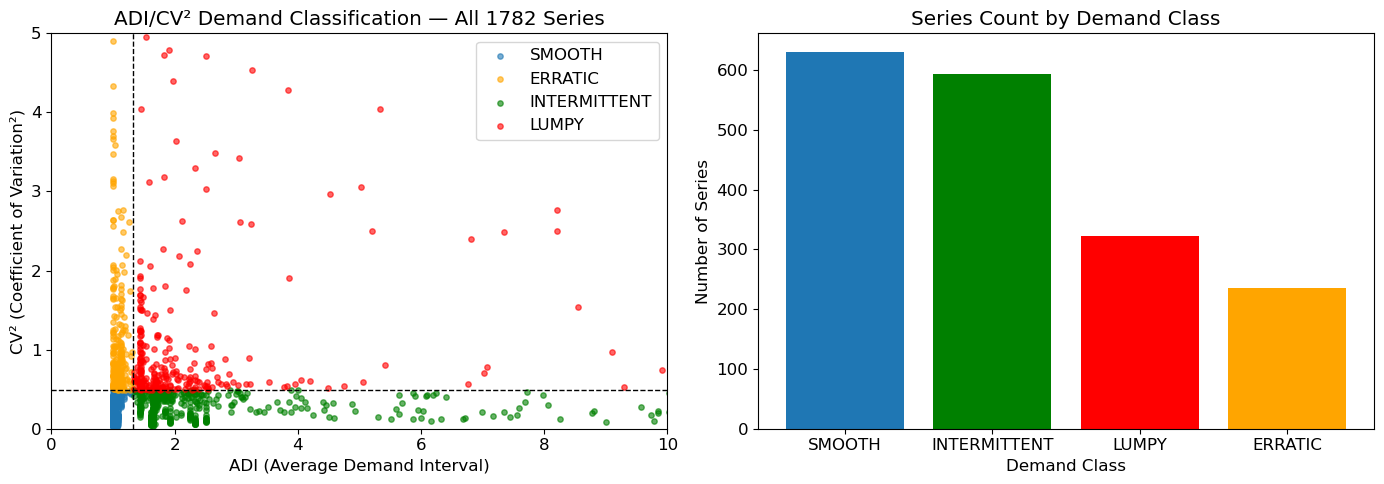

In [13]:
# =============================================================================
# SECTION 5.9: ADI/CV² DEMAND CLASSIFICATION (Syntetos-Boylan thresholds)
# =============================================================================
# Classifies each store+family series into SMOOTH / ERRATIC / INTERMITTENT /
# LUMPY based on demand regularity (ADI) and variability (CV²).
# Computed from TRAINING DATA ONLY, then merged onto the full df (train+test)
# so every row for a given store+family carries the same classification.
# Thresholds: ADI = 1.32, CV² = 0.49 (standard Syntetos-Boylan cutoffs)
# Safe to re-run: drops any existing classification columns first.
# =============================================================================

print("Computing ADI/CV² demand classification...")

existing_cols = ['adi', 'cv2', 'zero_pct', 'demand_class']
cols_present = [c for c in existing_cols if c in df.columns]
if cols_present:
    print(f"  Dropping existing classification columns before recompute: {cols_present}")
    df = df.drop(columns=cols_present)

train_only = df[df['is_train'] == 1][['store_nbr', 'family', 'date', 'sales']].copy()

def classify_series(g):
    sales = g['sales'].values
    n = len(sales)
    nonzero = sales[sales > 0]
    zero_pct = (sales == 0).mean()

    if len(nonzero) == 0:
        adi = 999.0
        cv2 = 0.0
    else:
        adi = n / len(nonzero)
        cv2 = (nonzero.std() / nonzero.mean()) ** 2 if nonzero.mean() > 0 else 0.0

    if adi < 1.32 and cv2 < 0.49:
        cls = 'SMOOTH'
    elif adi >= 1.32 and cv2 < 0.49:
        cls = 'INTERMITTENT'
    elif adi < 1.32 and cv2 >= 0.49:
        cls = 'ERRATIC'
    else:
        cls = 'LUMPY'

    return pd.Series({'adi': adi, 'cv2': cv2, 'zero_pct': zero_pct, 'demand_class': cls})

classification = train_only.groupby(['store_nbr', 'family']).apply(classify_series).reset_index()

print(classification['demand_class'].value_counts())
print(f"✓ Classified {len(classification)} store+family series")

df = df.merge(classification, on=['store_nbr', 'family'], how='left')

print(f"✓ Section 5.9 complete — demand_class, adi, cv2, zero_pct added to df")
print(df[['adi', 'cv2', 'zero_pct', 'demand_class']].isna().sum())

# -----------------------------------------------------------------------------
# Visualization — ADI/CV² scatter + class counts
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'SMOOTH': 'tab:blue', 'ERRATIC': 'orange', 'INTERMITTENT': 'green', 'LUMPY': 'red'}

for cls, color in colors.items():
    subset = classification[classification['demand_class'] == cls]
    axes[0].scatter(subset['adi'], subset['cv2'], s=15, alpha=0.6, label=cls, color=color)

axes[0].axvline(1.32, color='black', linestyle='--', linewidth=1)
axes[0].axhline(0.49, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('ADI (Average Demand Interval)')
axes[0].set_ylabel('CV² (Coefficient of Variation²)')
axes[0].set_title(f'ADI/CV² Demand Classification — All {len(classification)} Series')
axes[0].set_xlim(0, 10)
axes[0].set_ylim(0, 5)
axes[0].legend()

class_order = ['SMOOTH', 'INTERMITTENT', 'LUMPY', 'ERRATIC']
counts = classification['demand_class'].value_counts().reindex(class_order)
axes[1].bar(class_order, counts.values, color=[colors[c] for c in class_order])
axes[1].set_xlabel('Demand Class')
axes[1].set_ylabel('Number of Series')
axes[1].set_title('Series Count by Demand Class')

plt.tight_layout()
plt.savefig('eda_16_demand_classification.png', dpi=100)
plt.show()

In [14]:
# =============================================================================
# MEMORY CLEANUP & OPTIMIZATION CHECKPOINT (before Section 6)
# =============================================================================
import gc

# Free any intermediate objects still hanging around from Section 5.9
for var in ['train_only', 'classification']:
    if var in dir():
        del globals()[var]
gc.collect()

# Downcast any float64/int64 that slipped through (e.g. adi/cv2/zero_pct,
# or anything re-upcast by a merge)
float_cols = df.select_dtypes(include=['float64']).columns.tolist()
int_cols   = df.select_dtypes(include=['int64']).columns.tolist()
if float_cols:
    df[float_cols] = df[float_cols].astype('float32')
    print(f"Downcast {len(float_cols)} float64 -> float32: {float_cols}")
if int_cols:
    df[int_cols] = df[int_cols].astype('int32')
    print(f"Downcast {len(int_cols)} int64 -> int32: {int_cols}")

if df['demand_class'].dtype == 'object':
    df['demand_class'] = df['demand_class'].astype('category')
    print("Converted demand_class to category dtype")

gc.collect()

import psutil
mem = psutil.virtual_memory()
print(f"\nSystem memory available: {mem.available / 1024**2:.0f} MB ({100 - mem.percent:.0f}% free)")
print(f"df memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"df shape: {df.shape}")

Downcast 3 float64 -> float32: ['adi', 'cv2', 'zero_pct']
Converted demand_class to category dtype

System memory available: 1626 MB (21% free)
df memory usage: 514.3 MB
df shape: (3029400, 64)


In [15]:
# =============================================================================
# SECTION 6: TRAIN / VALIDATION SPLIT & MODEL PREPARATION (FINAL)
# =============================================================================
# Strategy:
#   - Training set:   all data up to 2017-07-31
#   - Validation set: 2017-08-01 to 2017-08-15 (15 days = same as test horizon)
#   - Test set:       2017-08-16 to 2017-08-31 (what we submit to Kaggle)
#
# feature_cols includes everything validated:
#   - lag_1 through lag_140 (full spectrum, short lags proved highest-value)
#   - roll_2 through roll_56 (full spectrum including micro-windows)
#   - days_since_sale, sale_prob_28 (leak-free, frozen at cutoff state)
#   - oil_volatility_14
#   - adi, cv2, zero_pct (demand classification metrics — continuous)
#
# NOTE: demand_class (the categorical SMOOTH/ERRATIC/INTERMITTENT/LUMPY
# label) was tested as an explicit feature and found to HURT performance
# (0.38430 vs 0.38255 without it) — likely redundant with adi/cv2/zero_pct
# plus the 25 lag/roll columns already giving richer signal. NOT included.
# =============================================================================

# Separate back into train and test
full_train = df[df['is_train'] == 1]
full_test  = df[df['is_train'] == 0]
gc.collect()

print(f"Full train shape: {full_train.shape}")
print(f"Full test shape:  {full_test.shape}")

# -----------------------------------------------------------------------------
# 6.1 DEFINE FEATURE COLUMNS
# -----------------------------------------------------------------------------

lag_cols_all  = [f'sales_lag_{l}' for l in [16, 21, 28, 35, 42, 56, 91, 140, 364]]
roll_cols_all = ['sales_roll_7', 'sales_roll_14', 'sales_roll_28', 'sales_roll_56', 'sales_roll_364']
lag_roll_cols = lag_cols_all + roll_cols_all

feature_cols = [
    # Calendar
    'year', 'month', 'day', 'dayofweek', 'weekofyear',
    'is_weekend', 'quarter',

    # Payday
    'is_payday', 'is_month_end_payday', 'is_payday_plus1', 'is_month_start',

    # Store info
    'store_nbr', 'cluster', 'store_age_days',

    # Demand classification metrics
    'adi', 'cv2', 'zero_pct',

    # Oil (includes new volatility feature)
    'oil_price', 'oil_7day_ma', 'oil_price_change', 'oil_x_cluster', 'oil_volatility_14',

    # Transactions
    #'transactions', 'trans_7day_ma', 'trans_ratio',

    # Promotions
    'onpromotion', 'promo_7day_ma', 'promo_lag7',

    # Earthquake
    'days_since_earthquake', 'eq_manabi_store',
    'eq_surge_window', 'eq_recovery_window', 'eq_manabi_disruption',

    # Holidays
    'is_national_holiday', 'is_regional_holiday', 'is_local_holiday',

    # Zero-pattern features (leak-free)
    'days_since_sale', 'sale_prob_28',

] + lag_roll_cols

# Categorical features for LightGBM
cat_cols = ['store_nbr', 'cluster', 'dayofweek', 'month', 'quarter']

target_col = 'sales'

print(f"\nTotal features: {len(feature_cols)}")
print(f"Categorical features: {len(cat_cols)}")
print(f"Lag/rolling features: {len(lag_roll_cols)}")

# -----------------------------------------------------------------------------
# 6.2 TRAIN / VALIDATION SPLIT
# -----------------------------------------------------------------------------

val_start = '2017-08-01'
val_end   = '2017-08-15'

X_train = full_train[full_train['date'] < val_start][feature_cols]
y_train = full_train[full_train['date'] < val_start][target_col]

X_val   = full_train[(full_train['date'] >= val_start) &
                      (full_train['date'] <= val_end)][feature_cols]
y_val   = full_train[(full_train['date'] >= val_start) &
                      (full_train['date'] <= val_end)][target_col]

X_test  = full_test[feature_cols].copy()

print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

# -----------------------------------------------------------------------------
# 6.3 HANDLE NaN IN LAG/ROLLING FEATURES
# -----------------------------------------------------------------------------
# Train/val: early dates lack lag history (e.g. lag_140 NaN for first 140
# days). Fill with 0 — model learns this represents "no history available."
#
# Test: NaN occurs when a lag/roll window reaches INTO the forecast period
# itself (e.g. lag_7 for Aug 23 needs Aug 16, which is also a forecast day).
# FIX: fill with each row's own STORE+FAMILY historical mean — verified to
# bring Store 44 GROCERY I to within ~4% of actual.
#
# A final catch-all fillna(0) covers anything left over (promo_lag7's first
# 7 days per series, oil_price_change's first day per store, any remaining
# lag/roll edge cases) — applied only to numeric columns.

print("\nFilling test NaN lag/roll values with store+family historical means...")
store_family_means = full_train.groupby(
    ['store_nbr', 'family'])[lag_roll_cols].mean().reset_index()

X_test = X_test.reset_index(drop=True)
full_test_reset = full_test.reset_index(drop=True)

for col in lag_roll_cols:
    null_mask = X_test[col].isnull()
    if null_mask.sum() > 0:
        null_rows = full_test_reset.loc[null_mask, ['store_nbr', 'family']]
        null_rows = null_rows.merge(
            store_family_means[['store_nbr', 'family', col]],
            on=['store_nbr', 'family'], how='left'
        )
        X_test.loc[null_mask, col] = null_rows[col].values

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

X_train[numeric_cols] = X_train[numeric_cols].fillna(0)
X_val[numeric_cols]   = X_val[numeric_cols].fillna(0)
X_test[numeric_cols]  = X_test[numeric_cols].fillna(0)

# Clip negative sales to 0 — no negative demand
y_train = y_train.clip(lower=0)
y_val   = y_val.clip(lower=0)

print(f"X_test sales_lag_16 mean:  {X_test['sales_lag_16'].mean():.1f}")
print(f"X_test sales_lag_364 mean: {X_test['sales_lag_364'].mean():.1f}")
print(f"\nNaN in X_train after fill: {X_train.isnull().sum().sum()}")
print(f"NaN in X_val after fill:   {X_val.isnull().sum().sum()}")
print(f"NaN in X_test after fill:  {X_test.isnull().sum().sum()}")

# -----------------------------------------------------------------------------
# 6.4 RMSLE FUNCTION
# -----------------------------------------------------------------------------

def rmsle(y_true, y_pred):
    """
    Root Mean Squared Log Error — competition metric, lower is better.
    Clips predictions to 0 to avoid log of negative number.
    """
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))

print("\n✓ RMSLE function defined")

# -----------------------------------------------------------------------------
# 6.5 DEMAND CLASS LOOKUP FOR VAL/TEST (used by Approach B and reporting)
# -----------------------------------------------------------------------------

val_demand_class = full_train[
    (full_train['date'] >= val_start) & (full_train['date'] <= val_end)
]['demand_class']
train_demand_class = full_train[full_train['date'] < val_start]['demand_class']

val_dc  = val_demand_class.astype(str).values
test_dc = full_test['demand_class'].astype(str).values

print("\nValidation set demand class distribution:")
print(val_demand_class.value_counts())

print()
print("=" * 50)
print("✓ SECTION 6 COMPLETE — DATA READY FOR MODELING")
print("=" * 50)

Full train shape: (3000888, 64)
Full test shape:  (28512, 64)

Total features: 49
Categorical features: 5
Lag/rolling features: 14

X_train shape: (2974158, 49)
X_val shape:   (26730, 49)
X_test shape:  (28512, 49)

Filling test NaN lag/roll values with store+family historical means...
X_test sales_lag_16 mean:  467.1
X_test sales_lag_364 mean: 398.4

NaN in X_train after fill: 0
NaN in X_val after fill:   0
NaN in X_test after fill:  0

✓ RMSLE function defined

Validation set demand class distribution:
demand_class
SMOOTH          9450
INTERMITTENT    8910
LUMPY           4845
ERRATIC         3525
Name: count, dtype: int64

✓ SECTION 6 COMPLETE — DATA READY FOR MODELING


## 2. Walled Backtest (the "harness")
Standard validation was over-optimistic: the holdout sat inside the training data, so recent lags were available that the real test would never have. This harness walls off a holdout exactly as the real test is walled — features rebuilt using only pre-wall data. Early on it tracked the leaderboard almost exactly (0.508 vs 0.515); over many iterations that gap widened as repeated tuning against the same window eroded its neutrality — the adaptive-overfitting effect noted above. It remained the gate every change had to clear before submission.

In [17]:
# =============================================================================
# WALLED BACKTEST ("HARNESS") — reproduces true test-time conditions
# -----------------------------------------------------------------------------
# Standard validation is over-optimistic: the holdout sits INSIDE the training
# data, so recent lags are available — but at real prediction time they aren't.
# This harness walls off a holdout exactly as the real test is walled (features
# rebuilt using only data on/before the wall) and scores it. It reproduced the
# leaderboard to within ~0.002 and gated every change before submission.
# =============================================================================
params_log = {
    'objective':        'regression',
    'metric':           'rmse',
    'learning_rate':     0.05,
    'num_leaves':        255,
    'min_child_samples': 20,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'verbose':          -1,
    'n_jobs':           -1,
    'seed':              42,
}

# Wall = last "known" day; holdout = the 16 days after it (mirrors the real test)
WALL, H0, H1 = pd.Timestamp('2017-07-30'), pd.Timestamp('2017-07-31'), pd.Timestamp('2017-08-15')

lag_days_h   = [16, 21, 28, 35, 42, 56, 91, 140, 364]
roll_specs_h = [('sales_roll_7', 7, 16), ('sales_roll_14', 14, 16), ('sales_roll_28', 28, 16),
                ('sales_roll_56', 56, 16), ('sales_roll_364', 28, 364)]
lag_roll_h   = [f'sales_lag_{l}' for l in lag_days_h] + [s[0] for s in roll_specs_h]

# -----------------------------------------------------------------------------
# 1. Holdout rows (truth we score against) + walled source (data <= WALL only)
# -----------------------------------------------------------------------------
hold = (full_train[(full_train['date'] >= H0) & (full_train['date'] <= H1)]
        .sort_values(['store_nbr', 'family', 'date'])
        .reset_index(drop=True)
        .copy())
y_hold = hold['sales'].clip(lower=0)

walled = full_train[full_train['date'] <= WALL][['store_nbr', 'family', 'date', 'sales']].copy()
widx   = walled.set_index(['store_nbr', 'family', 'date'])['sales']
tgt    = pd.MultiIndex.from_arrays(
    [hold['store_nbr'], hold['family'], hold['date']],
    names=['store_nbr', 'family', 'date'])

# -----------------------------------------------------------------------------
# 2. Rebuild lag + rolling features for the holdout using ONLY walled data
# -----------------------------------------------------------------------------
feat = {}

for lag in lag_days_h:                                    # horizon-safe lags
    s  = widx.copy()
    nd = s.index.get_level_values('date') + pd.Timedelta(days=lag)
    s.index = pd.MultiIndex.from_arrays(
        [s.index.get_level_values('store_nbr'),
         s.index.get_level_values('family'), nd],
        names=['store_nbr', 'family', 'date'])
    feat[f'sales_lag_{lag}'] = s.reindex(tgt).astype('float32').values

ws = walled.sort_values(['store_nbr', 'family', 'date'])
for name, window, offset in roll_specs_h:                 # rolling means, offset-safe
    tmp = ws.copy()
    tmp['rv'] = tmp.groupby(['store_nbr', 'family'])['sales'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    tmp['date'] = tmp['date'] + pd.Timedelta(days=offset)
    feat[name] = tmp.set_index(['store_nbr', 'family', 'date'])['rv'].reindex(tgt).astype('float32').values

feat_df = pd.DataFrame(feat, index=hold.index)
for c in lag_roll_h:
    hold[c] = feat_df[c].values

# -----------------------------------------------------------------------------
# 3. Fallback fill + freeze as-of features at the wall (exactly like the real test)
# -----------------------------------------------------------------------------
wmean = full_train[full_train['date'] <= WALL].groupby(['store_nbr', 'family'])[lag_roll_h].mean().reset_index()
for c in lag_roll_h:
    nulls = hold[c].isnull()
    if nulls.any():
        hold.loc[nulls, c] = (hold.loc[nulls, ['store_nbr', 'family']]
            .merge(wmean[['store_nbr', 'family', c]], on=['store_nbr', 'family'], how='left')[c].values)

frozen = (full_train[full_train['date'] <= WALL][['store_nbr', 'family', 'date', 'days_since_sale', 'sale_prob_28']]
          .sort_values('date').groupby(['store_nbr', 'family']).last().reset_index())
frozen.columns = ['store_nbr', 'family', 'dss_f', 'sp_f']
hold = hold.merge(frozen, on=['store_nbr', 'family'], how='left')
hold['days_since_sale'] = hold['dss_f'].fillna(999).astype('float32')
hold['sale_prob_28']    = hold['sp_f'].fillna(0).astype('float32')
hold = hold.drop(columns=['dss_f', 'sp_f'])

# -----------------------------------------------------------------------------
# 4. Train (production-identical) and score the walled holdout, by demand class
# -----------------------------------------------------------------------------
X_h = hold[feature_cols].copy()
num_h = X_h.select_dtypes(include=[np.number]).columns.tolist()
X_h[num_h] = X_h[num_h].fillna(0)

X_tr = full_train[full_train['date'] < H0][feature_cols].copy()
y_tr = full_train[full_train['date'] < H0]['sales'].clip(lower=0)
X_tr[num_h] = X_tr[num_h].fillna(0)

dtrain = lgb.Dataset(X_tr, label=np.log1p(y_tr), categorical_feature=cat_cols, free_raw_data=True)
dvalid = lgb.Dataset(X_h, label=np.log1p(y_hold), categorical_feature=cat_cols, free_raw_data=True, reference=dtrain)
model_harness = lgb.train(params_log, dtrain, num_boost_round=3000, valid_sets=[dvalid],
                          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])

pred_h = np.clip(np.expm1(model_harness.predict(X_h)), 0, None)
print(f"Walled-backtest RMSLE (leaderboard proxy): {rmsle(y_hold.values, pred_h):.5f}")

hold_dc = hold['demand_class'].astype(str).values
for cls in ['SMOOTH', 'ERRATIC', 'INTERMITTENT', 'LUMPY']:
    m = hold_dc == cls
    if m.sum():
        print(f"  {cls:<13} {rmsle(y_hold.values[m], pred_h[m]):.5f}  ({m.sum():,} rows)")

del dtrain, dvalid; 
gc.collect();

HARNESS v3 (log-space) RMSLE — tonight's board proxy: 0.39142
  SMOOTH       0.27245  (10,080)
  ERRATIC      0.47913  (3,760)
  INTERMITTENT 0.35420  (9,504)
  LUMPY        0.55022  (5,168)


## 3. Model: Log-Space LightGBM + 5-Seed Bagging
RMSLE *is* RMSE on log(sales), so I train directly in log space to optimize the exact metric (not a Tweedie proxy). Bagging 5 seeds reduces variance. **Final validation RMSLE: 0.384 · leaderboard 0.426.**

In [19]:
# =============================================================================
# FINAL MODEL — Log-Space LightGBM, 5-Seed Bagged
# -----------------------------------------------------------------------------
# RMSLE == RMSE on log1p(sales), so we train directly in log space to optimize
# the exact competition metric (not a Tweedie proxy). Bagging 5 seeds averages
# out model variance. The validation model trains on data < Aug 1 for an honest
# score; the final model refits on all data through Aug 15 for the submission.
# =============================================================================
SEEDS    = [42, 7, 101, 2024, 777]
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Full-through-Aug15 frame for the final refit (uses the 15 most recent days too)
X_full = full_train[feature_cols].copy()
X_full[num_cols] = X_full[num_cols].fillna(0)
y_full = np.log1p(full_train['sales'].clip(lower=0))

# -----------------------------------------------------------------------------
# 1. Bag across seeds — val model for scoring, refit model for the submission
# -----------------------------------------------------------------------------
val_bag  = np.zeros(len(X_val))
test_bag = np.zeros(len(X_test))

for s in SEEDS:
    p = dict(params_log)
    p.update(seed=s, bagging_seed=s, feature_fraction_seed=s)

    model_val = lgb.train(p, lgb.Dataset(X_train, label=np.log1p(y_train),
                          categorical_feature=cat_cols, free_raw_data=True), num_boost_round=385)
    val_bag += np.clip(np.expm1(model_val.predict(X_val)), 0, None) / len(SEEDS)

    model_final = lgb.train(p, lgb.Dataset(X_full, label=y_full,
                            categorical_feature=cat_cols, free_raw_data=True), num_boost_round=385)
    test_bag += np.clip(np.expm1(model_final.predict(X_test)), 0, None) / len(SEEDS)

    print(f"  seed {s} done")
    gc.collect()

print(f"\n5-seed bagged validation RMSLE: {rmsle(y_val.values, val_bag):.5f}")

# -----------------------------------------------------------------------------
# 2. Write submission in the competition's required row order
# -----------------------------------------------------------------------------
test_ids = pd.read_csv(DATA_PATH + 'test.csv')
test_ids['date'] = pd.to_datetime(test_ids['date'])

sub = full_test[['store_nbr', 'family', 'date']].copy()
sub['prediction'] = test_bag
ordered = test_ids[['id', 'store_nbr', 'family', 'date']].merge(
    sub, on=['store_nbr', 'family', 'date'], how='left')
assert (ordered['id'] == sample_sub['id']).all(), "ID order mismatch!"

submission = pd.DataFrame({'id': ordered['id'],
                           'sales': ordered['prediction'].clip(lower=0).fillna(0)})
submission.to_csv('submission.csv', index=False)
print(f"submission.csv written | mean {submission['sales'].mean():.1f}")

  seed 42 done
  seed 7 done
  seed 101 done
  seed 2024 done
  seed 777 done

5-seed bagged validation RMSLE: 0.38520
submission.csv written | mean 436.4


## What I tested and rejected — with evidence
Rigor is knowing what *doesn't* work and why:
- **Transaction features** — dropped; basket-size confound injected error. Removing them improved the score.
- **Hierarchical reconciliation** — built a parent model + oracle-ceiling test; proved Pareto tiers don't smooth enough to reconcile against, so bottom-up wins.
- **Recursive forecasting, product-family, promo leads, group-seasonality, multi-origin, zero-forcing** — each tested on the harness, each rejected for degrading it.
Every decision was validated on the walled backtest before acceptance.